This cell establishes the official PromptHMR repository as the active working directory for the notebook.

In [4]:
# CELL 0: Force the notebook to use the correct PromptHMR repository

from pathlib import Path
import os

REPO_DIR = Path("/home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR")

if not REPO_DIR.exists():
    raise FileNotFoundError(f"PromptHMR repository not found: {REPO_DIR}")

os.chdir(REPO_DIR)

print("USING REPO_DIR:")
print(REPO_DIR)

print("\nCURRENT DIRECTORY:")
print(Path.cwd())

print("\nOutput folder exists:")
print((REPO_DIR / "outputs/example_1_no_vis").exists())

print("\nOutput files:")
for p in sorted((REPO_DIR / "outputs/example_1_no_vis").iterdir()):
    print(" -", p.name)

USING REPO_DIR:
/home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR

CURRENT DIRECTORY:
/home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR

Output folder exists:
True

Output files:
 - detections.jpg
 - metadata.json
 - output.pt
 - person_000.ply
 - person_001.ply
 - person_002.ply
 - person_003.ply
 - person_004.ply
 - person_005.ply
 - person_006.ply
 - person_007.ply
 - person_008.ply
 - person_009.ply
 - person_010.ply
 - person_011.ply
 - person_012.ply
 - person_013.ply


This cell defines the general project structure.

In [34]:
# CELL 1: Configure project paths and ensure that the official PromptHMR repository exists

import os
import sys
import subprocess
from pathlib import Path

PROJECT_ROOT = Path.home() / "UA/master-ia/tava/prompthmr-method/prompthmr-project"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
EXTERNAL_DIR = PROJECT_ROOT / "external"
PHMR_REPO = EXTERNAL_DIR / "PromptHMR"
INPUT_DIR = PROJECT_ROOT / "inputs"
IMAGE_INPUT_DIR = INPUT_DIR / "images"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
INFERENCE_OUTPUT_DIR = OUTPUT_DIR / "inference"
REPORT_OUTPUT_DIR = OUTPUT_DIR / "reports"
EVALUATION_OUTPUT_DIR = OUTPUT_DIR / "evaluation"
LOG_DIR = PROJECT_ROOT / "logs"

for path in [
    PROJECT_ROOT,
    NOTEBOOK_DIR,
    EXTERNAL_DIR,
    IMAGE_INPUT_DIR,
    INFERENCE_OUTPUT_DIR,
    REPORT_OUTPUT_DIR,
    EVALUATION_OUTPUT_DIR,
    LOG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

if not PHMR_REPO.exists():
    subprocess.run(
        f"git clone https://github.com/yufu-wang/PromptHMR.git {PHMR_REPO}",
        shell=True,
        check=True,
    )

os.chdir(PHMR_REPO)
sys.path.insert(0, str(PHMR_REPO))

required_repo_items = [
    PHMR_REPO / "README.md",
    PHMR_REPO / "requirements.txt",
    PHMR_REPO / "data_config.py",
    PHMR_REPO / "scripts",
    PHMR_REPO / "prompt_hmr",
]

for item in required_repo_items:
    assert item.exists(), f"Missing required PromptHMR item: {item}"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PHMR_REPO:", PHMR_REPO)
print("Current directory:", Path.cwd())
print("Python executable:", sys.executable)
print("Kernel should be: phmr_pt24")

PROJECT_ROOT: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project
PHMR_REPO: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR
Current directory: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR
Python executable: /home/cris-sx/miniconda3/envs/phmr_pt24/bin/python
Kernel should be: phmr_pt24


This cell performs a complete environment validation for the PromptHMR deployment.

In [3]:
# CELL 2: Verify that the phmr_pt24 kernel uses GPU-compatible PyTorch and required PromptHMR packages

import os
import sys
import subprocess
import platform
from pathlib import Path

os.chdir(PHMR_REPO)
PYTHON = sys.executable

print("=" * 100)
print("ENVIRONMENT")
print("=" * 100)
print("Python executable:", PYTHON)
print("Python version:", sys.version)
print("Platform:", platform.platform())
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV"))
print("Current directory:", Path.cwd())

def run(cmd, allow_fail=False):
    print("\n" + "=" * 100)
    print("$", cmd)
    print("=" * 100)

    p = subprocess.run(
        cmd,
        shell=True,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )

    print(p.stdout)

    if p.returncode != 0 and not allow_fail:
        raise RuntimeError(
            f"Command failed with return code {p.returncode}\n"
            f"Command: {cmd}\n\n"
            f"Output:\n{p.stdout}"
        )

    return p

checks = [
    "import torch; "
    "print('torch:', torch.__version__); "
    "print('torch cuda:', torch.version.cuda); "
    "print('cuda available:', torch.cuda.is_available()); "
    "assert torch.cuda.is_available(), 'CUDA is not available'; "
    "print('gpu:', torch.cuda.get_device_name(0))",

    "import torchvision; print('torchvision:', torchvision.__version__)",
    "import smplx; print('smplx OK')",
    "import cv2; print('opencv:', cv2.__version__)",
    "import ultralytics; print('ultralytics OK')",
    "import viser; print('viser OK')",
    "import open3d; print('open3d OK')",
    "import pyrender; print('pyrender OK')",
    "import timm; print('timm OK')",
    "import yacs; print('yacs OK')",
    "import torch_scatter; print('torch_scatter OK')",
    "import xformers; print('xformers OK')",
    "import chumpy; print('chumpy OK')",
]

for code in checks:
    run(f'"{PYTHON}" -c "{code}"', allow_fail=False)

print("\nAll core PromptHMR dependencies are available and CUDA is active.")

ENVIRONMENT
Python executable: /home/cris-sx/miniconda3/envs/phmr_pt24/bin/python
Python version: 3.11.9 (main, Apr 19 2024, 16:48:06) [GCC 11.2.0]
Platform: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.35
CONDA_DEFAULT_ENV: phmr_pt24
Current directory: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR

$ "/home/cris-sx/miniconda3/envs/phmr_pt24/bin/python" -c "import torch; print('torch:', torch.__version__); print('torch cuda:', torch.version.cuda); print('cuda available:', torch.cuda.is_available()); assert torch.cuda.is_available(), 'CUDA is not available'; print('gpu:', torch.cuda.get_device_name(0))"
torch: 2.4.0+cu121
torch cuda: 12.1
cuda available: True
gpu: NVIDIA GeForce RTX 4060 Laptop GPU


$ "/home/cris-sx/miniconda3/envs/phmr_pt24/bin/python" -c "import torchvision; print('torchvision:', torchvision.__version__)"
torchvision: 0.19.0+cu121


$ "/home/cris-sx/miniconda3/envs/phmr_pt24/bin/python" -c "import smplx; print('smp

This cell verifies that all critical PromptHMR resources are present after downloading the pretrained data and body models

In [4]:
# CELL 6: Verify required PromptHMR files after data/model download

from pathlib import Path
import os

os.chdir(PHMR_REPO)

required_paths = [
    "data/pretrain/phmr/config.yaml",
    "data/pretrain/phmr/checkpoint.ckpt",
    "data/pretrain/yolov8x.pt",
    "data/pretrain/camcalib_sa_biased_l2.ckpt",
    "data/body_models/smpl",
    "data/body_models/smplx",
    "data/body_models/smplx2smpl.pkl",
    "data/examples/example_1.jpg",
]

missing = []

for item in required_paths:
    path = Path(item)
    if path.exists():
        print(f"[OK] {item}")
    else:
        print(f"[MISSING] {item}")
        missing.append(item)

if missing:
    raise FileNotFoundError(
        "Some required PromptHMR files are missing. "
        "Run CELL 4 and CELL 5 again or place the files manually.\n"
        f"Missing files/folders: {missing}"
    )

print("\nAll required PromptHMR files are present.")

[OK] data/pretrain/phmr/config.yaml
[OK] data/pretrain/phmr/checkpoint.ckpt
[OK] data/pretrain/yolov8x.pt
[OK] data/pretrain/camcalib_sa_biased_l2.ckpt
[OK] data/body_models/smpl
[OK] data/body_models/smplx
[OK] data/body_models/smplx2smpl.pkl
[OK] data/examples/example_1.jpg

All required PromptHMR files are present.


This cell loads both the SMPL-X body model and the PromptHMR pretrained model onto the CUDA device.

In [ ]:
# CELL 7: Load SMPL-X and PromptHMR on GPU

import os
import sys
from pathlib import Path

import torch

os.chdir(PHMR_REPO)
sys.path.insert(0, str(PHMR_REPO))

from data_config import SMPLX_PATH
from prompt_hmr import load_model_from_folder
from prompt_hmr.smpl_family import SMPLX

assert torch.cuda.is_available(), "CUDA is required for this deployment."

DEVICE = torch.device("cuda")
torch.backends.cudnn.benchmark = True

print("Using device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))

print("Loading SMPL-X...")
smplx_model = SMPLX(SMPLX_PATH).to(DEVICE)
print("SMPL-X loaded on GPU.")

print("Loading PromptHMR checkpoint...")
phmr_model = load_model_from_folder("data/pretrain/phmr")
phmr_model = phmr_model.to(DEVICE)
phmr_model.eval()
print("PromptHMR loaded on GPU.")

print("Model smoke test completed successfully.")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Loading SMPL-X...
SMPL-X loaded on GPU.
Loading PromptHMR checkpoint...


/home/cris-sx/miniconda3/envs/phmr_pt24/lib/python3.11/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/home/cris-sx/miniconda3/envs/phmr_pt24/lib/python3.11/site-packages/xformers/ops/fmha/flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_bwd")


Not using DINOv2 weight
PromptHMR loaded on GPU.
Model smoke test completed successfully.


This cell implements a direct single-image PromptHMR inference pipeline without relying on the interactive or world-coordinate video modules. It loads the example image, applies YOLOv8 person detection, prepares PromptHMR inputs using bounding boxes as prompts, runs GPU inference with mixed precision, and saves the predicted pose, shape parameters, translation, rotation matrices, vertices, joints, and camera intrinsics. It also exports detection visualizations, PLY mesh files, tensor outputs, and metadata containing runtime and GPU memory usage, making it a compact and reproducible image-only inference experiment.

In [6]:
# CELL 8: Run PromptHMR image-only inference without importing the world-video pipeline

import os
import sys
import json
import time
from pathlib import Path

import cv2
import torch
from torch.amp import autocast
from ultralytics import YOLO

os.chdir(PHMR_REPO)
sys.path.insert(0, str(PHMR_REPO))

from data_config import SMPLX_PATH
from prompt_hmr import load_model_from_folder
from prompt_hmr.smpl_family import SMPLX
from prompt_hmr.models.inference import prepare_batch
from prompt_hmr.utils.visualizer import draw_boxes, save_ply

assert torch.cuda.is_available(), "CUDA is not available. This project must use GPU whenever possible."

DEVICE = torch.device("cuda")
torch.backends.cudnn.benchmark = True

print("Using device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))

image_path = PHMR_REPO / "data/examples/example_1.jpg"
output_dir = INFERENCE_OUTPUT_DIR / "example_1_basic_image_only"
output_dir.mkdir(parents=True, exist_ok=True)

assert image_path.exists(), f"Image not found: {image_path}"
assert (PHMR_REPO / "data/pretrain/phmr/config.yaml").exists(), "Missing PromptHMR config.yaml"
assert (PHMR_REPO / "data/pretrain/phmr/checkpoint.ckpt").exists(), "Missing PromptHMR checkpoint.ckpt"
assert (PHMR_REPO / "data/pretrain/yolov8x.pt").exists(), "Missing yolov8x.pt"

start_total = time.perf_counter()

print("Reading image...")
img_bgr = cv2.imread(str(image_path))
assert img_bgr is not None, f"OpenCV could not read image: {image_path}"
img_rgb = img_bgr[:, :, ::-1]

print("Loading SMPL-X on GPU...")
smplx = SMPLX(SMPLX_PATH).to(DEVICE)

print("Loading YOLO...")
yolo = YOLO(str(PHMR_REPO / "data/pretrain/yolov8x.pt"))

print("Loading PromptHMR on GPU...")
phmr = load_model_from_folder("data/pretrain/phmr")
phmr = phmr.to(DEVICE)
phmr.eval()

print("Running YOLO person detection...")
detection = yolo(str(image_path), verbose=False, conf=0.3, classes=0)
boxes = detection[0].boxes.data.cpu()

if boxes is None or len(boxes) == 0:
    raise RuntimeError("No person detected. Try lowering the confidence threshold.")

print("Detected people:", len(boxes))

detection_img = draw_boxes(img_rgb, boxes[:, :4], thickness=4, numbered=True)
cv2.imwrite(str(output_dir / "detections.jpg"), detection_img[:, :, ::-1])

inputs = [{
    "image_cv": img_rgb,
    "boxes": boxes,
    "text": None,
    "masks": None,
}]

print("Running PromptHMR inference on GPU...")
torch.cuda.reset_peak_memory_stats()

start_inference = time.perf_counter()

with torch.no_grad():
    with autocast("cuda"):
        batch = prepare_batch(inputs, img_size=896, interaction=False)
        output = phmr(batch, use_mean_hands=True)[0]

torch.cuda.synchronize()

inference_time = time.perf_counter() - start_inference
peak_gpu_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

keys = [
    "pose",
    "betas",
    "transl",
    "rotmat",
    "vertices",
    "body_joints",
    "cam_int",
]

output_cpu = {
    key: output[key].detach().cpu()
    for key in keys
}

torch.save(output_cpu, output_dir / "output.pt")

print("Saving PLY meshes...")
vertices = output_cpu["vertices"].numpy()

for person_idx in range(vertices.shape[0]):
    save_ply(
        vertices[person_idx],
        smplx.faces,
        filename=str(output_dir / f"person_{person_idx:03d}.ply"),
    )

total_time = time.perf_counter() - start_total

metadata = {
    "method": "PromptHMR",
    "mode": "basic_image_only_no_world_video_pipeline",
    "image": str(image_path),
    "output_dir": str(output_dir),
    "device": "cuda",
    "gpu": torch.cuda.get_device_name(0),
    "num_people": int(vertices.shape[0]),
    "inference_time_seconds": float(inference_time),
    "total_time_seconds": float(total_time),
    "peak_gpu_memory_mb": float(peak_gpu_memory_mb),
    "tensor_shapes": {
        key: list(value.shape)
        for key, value in output_cpu.items()
    },
}

with open(output_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("\nDONE.")
print("Output directory:", output_dir)
print("Saved output.pt:", output_dir / "output.pt")
print("Saved detections.jpg:", output_dir / "detections.jpg")
print("Saved metadata.json:", output_dir / "metadata.json")
print("Inference time:", inference_time)
print("Peak GPU memory MB:", peak_gpu_memory_mb)

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Reading image...
Loading SMPL-X on GPU...
Loading YOLO...
Loading PromptHMR on GPU...
Not using DINOv2 weight
Running YOLO person detection...
Detected people: 14
Running PromptHMR inference on GPU...
Saving PLY meshes...

DONE.
Output directory: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/inference/example_1_basic_image_only
Saved output.pt: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/inference/example_1_basic_image_only/output.pt
Saved detections.jpg: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/inference/example_1_basic_image_only/detections.jpg
Saved metadata.json: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/inference/example_1_basic_image_only/metadata.json
Inference time: 2.9205696319995695
Peak GPU memory MB: 6865.3349609375


This cell validates and inspects the files generated by the previous image-only inference step. It lists the output directory contents, loads the metadata file, prints execution information, and reads the saved output.pt tensor file to display the shape and data type of each predicted output.

In [7]:
# CELL 9: Inspect PromptHMR image-only inference output

import json
import torch
from pathlib import Path

out_dir = INFERENCE_OUTPUT_DIR / "example_1_basic_image_only"

assert out_dir.exists(), f"Output directory not found: {out_dir}"
assert (out_dir / "output.pt").exists(), "Missing output.pt"
assert (out_dir / "metadata.json").exists(), "Missing metadata.json"

print("Output files:")
for p in sorted(out_dir.iterdir()):
    print(" -", p.name)

print("\nMetadata:")
metadata = json.loads((out_dir / "metadata.json").read_text())
print(json.dumps(metadata, indent=2))

print("\nTensor shapes:")
output = torch.load(out_dir / "output.pt", map_location="cpu")

for key, value in output.items():
    print(f"{key}: shape={tuple(value.shape)}, dtype={value.dtype}")

Output files:
 - detections.jpg
 - metadata.json
 - output.pt
 - person_000.ply
 - person_001.ply
 - person_002.ply
 - person_003.ply
 - person_004.ply
 - person_005.ply
 - person_006.ply
 - person_007.ply
 - person_008.ply
 - person_009.ply
 - person_010.ply
 - person_011.ply
 - person_012.ply
 - person_013.ply

Metadata:
{
  "method": "PromptHMR",
  "mode": "basic_image_only_no_world_video_pipeline",
  "image": "/home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/data/examples/example_1.jpg",
  "output_dir": "/home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/inference/example_1_basic_image_only",
  "device": "cuda",
  "gpu": "NVIDIA GeForce RTX 4060 Laptop GPU",
  "num_people": 14,
  "inference_time_seconds": 2.9205696319995695,
  "total_time_seconds": 101.93796054500035,
  "peak_gpu_memory_mb": 6865.3349609375,
  "tensor_shapes": {
    "pose": [
      14,
      132
    ],
    "betas": [
      14,
      10
    ],
    "transl"

This cell executes the official PromptHMR single-image demo script using the repository’s original demo_phmr.py file. It confirms that the repository, demo script, SMPL-X folder, and example image exist, then launches the demo with CUDA enabled and gravity alignment activated.

In [7]:
# CELL 10: Run official single-image PromptHMR demo from the correct repository

import os  
import sys
import subprocess
from pathlib import Path

PROJECT_ROOT = Path.home() / "UA/master-ia/tava/prompthmr-method/prompthmr-project"
PHMR_REPO = PROJECT_ROOT / "external" / "PromptHMR"

assert PHMR_REPO.exists(), f"PromptHMR repo not found: {PHMR_REPO}"
assert (PHMR_REPO / "scripts/demo_phmr.py").exists(), "demo_phmr.py not found"
assert (PHMR_REPO / "data/body_models/smplx").exists(), "SMPL-X folder not found"
assert (PHMR_REPO / "data/examples/example_1.jpg").exists(), "example_1.jpg not found"

os.chdir(PHMR_REPO)

print("Running from:", Path.cwd())
print("Python executable:", sys.executable)

cmd = f"""
CUDA_VISIBLE_DEVICES=0 "{sys.executable}" scripts/demo_phmr.py \
    --image data/examples/example_1.jpg \
    --gravity_align
"""

p = subprocess.run(
    cmd,
    shell=True,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)

print(p.stdout)
print("Return code:", p.returncode)

Running from: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR
Python executable: /home/cris-sx/miniconda3/envs/phmr_pt24/bin/python


: 

This code searches for the output.pt file generated by the official PromptHMR demo and inspects its contents. It loads the output tensor dictionary and prints all available keys, shapes, and data types.

In [8]:
# CELL 11: Inspect the output generated by the official PromptHMR demo

from pathlib import Path
import torch
import os

PROJECT_ROOT = Path.home() / "UA/master-ia/tava/prompthmr-method/prompthmr-project"
PHMR_REPO = PROJECT_ROOT / "external" / "PromptHMR"

os.chdir(PHMR_REPO)

print("Current directory:", Path.cwd())

possible_outputs = list(Path(".").glob("example_1*/output.pt"))

print("Found output.pt files:")
for p in possible_outputs:
    print(" -", p.resolve())

if not possible_outputs:
    raise FileNotFoundError(
        "Could not find example_1*/output.pt in the correct PromptHMR repo."
    )

output_path = possible_outputs[0]
print("\nUsing output:", output_path.resolve())

output = torch.load(output_path, map_location="cpu")

print("\nAvailable keys:")
for k, v in output.items():
    if hasattr(v, "shape"):
        print(f"{k}: shape={tuple(v.shape)}, dtype={v.dtype}")
    else:
        print(f"{k}: {type(v)}")

Current directory: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR
Found output.pt files:
 - /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/example_1.jpg/output.pt

Using output: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/example_1.jpg/output.pt

Available keys:
pose: shape=(14, 132), dtype=torch.float32
betas: shape=(14, 10), dtype=torch.float32
transl: shape=(14, 3), dtype=torch.float32
rotmat: shape=(14, 22, 3, 3), dtype=torch.float32
vertices: shape=(14, 10475, 3), dtype=torch.float32
body_joints: shape=(14, 25, 3), dtype=torch.float32
cam_int: shape=(14, 3, 3), dtype=torch.float32


This cell programmatically creates a standalone script named run_phmr_no_vis.py inside the repository’s tools directory. The script runs PromptHMR inference without requiring the Viser interactive visualization system, supports automatic YOLO detection or manual bounding-box prompts, saves detection images, predicted tensors, PLY meshes, and metadata, and records runtime and GPU memory consumption.

In [9]:
# CELL 12A: Create non-interactive PromptHMR inference script without Viser

import os
from pathlib import Path

PROJECT_ROOT = Path.home() / "UA/master-ia/tava/prompthmr-method/prompthmr-project"
PHMR_REPO = PROJECT_ROOT / "external" / "PromptHMR"

assert PHMR_REPO.exists(), f"PromptHMR repo not found: {PHMR_REPO}"

os.chdir(PHMR_REPO)

tools_dir = PHMR_REPO / "tools"
tools_dir.mkdir(parents=True, exist_ok=True)

script_path = tools_dir / "run_phmr_no_vis.py"

script_code = r'''
import os
import sys
import json
import time
import argparse
from pathlib import Path

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

REPO_DIR = Path(__file__).resolve().parents[1]
sys.path.insert(0, str(REPO_DIR))

import cv2
import torch
from torch.amp import autocast
from ultralytics import YOLO

from data_config import SMPLX_PATH
from prompt_hmr import load_model_from_folder
from prompt_hmr.smpl_family import SMPLX
from prompt_hmr.models.inference import prepare_batch
from prompt_hmr.utils.visualizer import draw_boxes, save_ply


def parse_manual_boxes(box_string):
    boxes = []

    for item in box_string.split(";"):
        item = item.strip()
        if not item:
            continue

        values = [float(x) for x in item.split(",")]

        if len(values) != 4:
            raise ValueError("Each manual box must have exactly 4 values: x1,y1,x2,y2")

        boxes.append(values)

    if len(boxes) == 0:
        raise ValueError("No valid manual boxes were provided.")

    return torch.tensor(boxes, dtype=torch.float32)


def main():
    parser = argparse.ArgumentParser(description="Run PromptHMR without Viser.")
    parser.add_argument("--image", type=str, required=True)
    parser.add_argument("--output-dir", type=str, required=True)
    parser.add_argument("--detect-conf", type=float, default=0.3)
    parser.add_argument("--manual-boxes", type=str, default=None)
    parser.add_argument("--model-folder", type=str, default="data/pretrain/phmr")
    parser.add_argument("--yolo-weights", type=str, default="data/pretrain/yolov8x.pt")
    parser.add_argument("--img-size", type=int, default=896)

    args = parser.parse_args()

    image_path = Path(args.image)
    output_dir = Path(args.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if not image_path.exists():
        raise FileNotFoundError(f"Input image not found: {image_path}")

    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available. This deployment is configured to use GPU.")

    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = True

    print("[INFO] Device:", device)
    print("[INFO] GPU:", torch.cuda.get_device_name(0))

    start_total = time.perf_counter()

    print("[INFO] Reading image...")
    img_bgr = cv2.imread(str(image_path))

    if img_bgr is None:
        raise RuntimeError(f"OpenCV could not read image: {image_path}")

    img_rgb = img_bgr[:, :, ::-1]

    print("[INFO] Loading SMPL-X on GPU...")
    smplx = SMPLX(SMPLX_PATH).to(device)

    print("[INFO] Loading PromptHMR on GPU...")
    phmr = load_model_from_folder(args.model_folder)
    phmr = phmr.to(device)
    phmr.eval()

    if args.manual_boxes is not None:
        print("[INFO] Using manual bounding-box prompts.")
        boxes = parse_manual_boxes(args.manual_boxes)
    else:
        print("[INFO] Running YOLO person detection...")
        yolo = YOLO(args.yolo_weights)
        detection = yolo(str(image_path), verbose=False, conf=args.detect_conf, classes=0)
        boxes = detection[0].boxes.data.cpu()

    if boxes is None or len(boxes) == 0:
        raise RuntimeError(
            "No person detected. Try lowering --detect-conf or use --manual-boxes."
        )

    print(f"[INFO] Number of person prompts: {len(boxes)}")

    detection_image = draw_boxes(img_rgb, boxes[:, :4], thickness=4, numbered=True)
    cv2.imwrite(str(output_dir / "detections.jpg"), detection_image[:, :, ::-1])

    inputs = [{
        "image_cv": img_rgb,
        "boxes": boxes,
        "text": None,
        "masks": None,
    }]

    print("[INFO] Running PromptHMR inference with CUDA autocast...")
    torch.cuda.reset_peak_memory_stats()

    start_inference = time.perf_counter()

    with torch.no_grad():
        with autocast("cuda"):
            batch = prepare_batch(inputs, img_size=args.img_size, interaction=False)
            output = phmr(batch, use_mean_hands=True)[0]

    torch.cuda.synchronize()

    inference_time = time.perf_counter() - start_inference
    peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

    keys = [
        "pose",
        "betas",
        "transl",
        "rotmat",
        "vertices",
        "body_joints",
        "cam_int",
    ]

    output_cpu = {}

    for key in keys:
        output_cpu[key] = output[key].detach().cpu()

    torch.save(output_cpu, output_dir / "output.pt")

    print("[INFO] Saving PLY meshes...")
    vertices = output_cpu["vertices"].numpy()

    for person_idx in range(vertices.shape[0]):
        save_ply(
            vertices[person_idx],
            smplx.faces,
            filename=str(output_dir / f"person_{person_idx:03d}.ply"),
        )

    total_time = time.perf_counter() - start_total

    metadata = {
        "method": "PromptHMR",
        "mode": "non_interactive_no_viser",
        "image": str(image_path),
        "output_dir": str(output_dir),
        "device": "cuda",
        "gpu": torch.cuda.get_device_name(0),
        "num_people": int(vertices.shape[0]),
        "detect_conf": float(args.detect_conf),
        "manual_boxes_used": args.manual_boxes is not None,
        "img_size": int(args.img_size),
        "inference_time_seconds": float(inference_time),
        "total_time_seconds": float(total_time),
        "peak_gpu_memory_mb": float(peak_mem_mb),
        "tensor_shapes": {
            key: list(value.shape)
            for key, value in output_cpu.items()
        },
    }

    with open(output_dir / "metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print("[DONE] PromptHMR inference completed.")
    print("[DONE] Output directory:", output_dir.resolve())
    print("[DONE] Inference time:", inference_time)
    print("[DONE] Peak GPU memory MB:", peak_mem_mb)


if __name__ == "__main__":
    main()
'''

script_path.write_text(script_code)

print("Created:", script_path)
print("Exists:", script_path.exists())

Created: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/tools/run_phmr_no_vis.py
Exists: True


This code applies the non-interactive PromptHMR script to a user-provided custom image named person.jpg. It checks that the image and script exist, defines the output directory, executes the script with YOLO-based automatic person detection, and raises an error if inference fails.

In [8]:
# CELL 12: Run PromptHMR on a custom image using automatic YOLO person detection

import os
import sys
import subprocess
from pathlib import Path

PROJECT_ROOT = Path.home() / "UA/master-ia/tava/prompthmr-method/prompthmr-project"
PHMR_REPO = PROJECT_ROOT / "external" / "PromptHMR"

IMAGE_INPUT_DIR = PROJECT_ROOT / "inputs" / "images"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
INFERENCE_OUTPUT_DIR = OUTPUT_DIR / "inference"

IMAGE_INPUT_DIR.mkdir(parents=True, exist_ok=True)
INFERENCE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

os.chdir(PHMR_REPO)

custom_image = IMAGE_INPUT_DIR / "person.jpg"
custom_output_dir = INFERENCE_OUTPUT_DIR / "custom_person_auto"

print("PHMR_REPO:", PHMR_REPO)
print("Custom image expected at:", custom_image)
print("Output dir:", custom_output_dir)
print("Python executable:", sys.executable)

assert custom_image.exists(), (
    f"Custom image not found: {custom_image}\n"
    "Put your image at this exact path and name it person.jpg"
)

assert (PHMR_REPO / "tools/run_phmr_no_vis.py").exists(), (
    "tools/run_phmr_no_vis.py does not exist. "
    "Run the cell that creates the non-interactive inference script first."
)

cmd = f"""
CUDA_VISIBLE_DEVICES=0 "{sys.executable}" tools/run_phmr_no_vis.py \
    --image "{custom_image}" \
    --output-dir "{custom_output_dir}" \
    --detect-conf 0.3
"""

p = subprocess.run(
    cmd,
    shell=True,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)

print(p.stdout)
print("Return code:", p.returncode)

if p.returncode != 0:
    raise RuntimeError("Custom PromptHMR inference failed.")
else:
    print("Custom PromptHMR inference completed successfully.")

PHMR_REPO: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR
Custom image expected at: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/inputs/images/person.jpg
Output dir: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/inference/custom_person_auto
Python executable: /home/cris-sx/miniconda3/envs/phmr_pt24/bin/python


KeyboardInterrupt: 

This cell represents an alternative or older version of the script-generation step for run_phmr_no_vis.py. It creates a similar non-interactive PromptHMR inference utility, including support for manual bounding boxes, YOLO detection, SMPL-X loading, tensor export, PLY mesh saving, and metadata writing.

In [11]:
# CELL 12B: Create the non-interactive PromptHMR inference script

from pathlib import Path
import os

REPO_DIR = Path.home() / "smpl_projects" / "PromptHMR"
os.chdir(REPO_DIR)

print("Current directory:", Path.cwd())

tools_dir = Path("tools")
tools_dir.mkdir(exist_ok=True)

script_path = tools_dir / "run_phmr_no_vis.py"

script_code = r'''
import os
import sys
import json
import argparse
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))

import cv2
import torch
import numpy as np
from torch.amp import autocast
from ultralytics import YOLO

from prompt_hmr import load_model_from_folder
from prompt_hmr.smpl_family import SMPLX
from prompt_hmr.models.inference import prepare_batch
from prompt_hmr.utils.visualizer import draw_boxes, save_ply


def parse_manual_boxes(box_string):
    boxes = []
    for item in box_string.split(";"):
        item = item.strip()
        if not item:
            continue
        values = [float(x) for x in item.split(",")]
        if len(values) != 4:
            raise ValueError("Each manual box must be x1,y1,x2,y2")
        boxes.append(values)

    if not boxes:
        raise ValueError("No valid manual boxes were provided.")

    return torch.tensor(boxes, dtype=torch.float32)


def main():
    parser = argparse.ArgumentParser(description="Run PromptHMR without Viser.")
    parser.add_argument("--image", type=str, required=True)
    parser.add_argument("--output-dir", type=str, required=True)
    parser.add_argument("--model-folder", type=str, default="data/pretrain/phmr")
    parser.add_argument("--smplx-path", type=str, default="data/body_models/smplx")
    parser.add_argument("--yolo-path", type=str, default="data/pretrain/yolov8x.pt")
    parser.add_argument("--detect-conf", type=float, default=0.3)
    parser.add_argument(
        "--manual-boxes",
        type=str,
        default=None,
        help='Manual boxes: "x1,y1,x2,y2;x1,y1,x2,y2". If provided, YOLO is skipped.'
    )

    args = parser.parse_args()

    image_path = Path(args.image)
    output_dir = Path(args.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if not image_path.exists():
        raise FileNotFoundError(f"Input image not found: {image_path}")

    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available. PromptHMR expects GPU execution.")

    print("[INFO] Loading image...")
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise RuntimeError(f"OpenCV could not read image: {image_path}")

    img_rgb = img_bgr[:, :, ::-1]

    print("[INFO] Loading SMPL-X...")
    smplx = SMPLX(args.smplx_path).cuda()

    print("[INFO] Loading PromptHMR...")
    phmr = load_model_from_folder(args.model_folder)

    if args.manual_boxes is not None:
        print("[INFO] Using manual bounding boxes.")
        boxes = parse_manual_boxes(args.manual_boxes)
    else:
        print("[INFO] Running YOLO person detector...")
        yolo = YOLO(args.yolo_path)
        detection = yolo(str(image_path), verbose=False, conf=args.detect_conf, classes=0)
        boxes = detection[0].boxes.data.cpu()

    if boxes is None or len(boxes) == 0:
        raise RuntimeError(
            "No people detected. Try --detect-conf 0.1 or use --manual-boxes."
        )

    print(f"[INFO] Detected/promped people: {len(boxes)}")

    box_img = draw_boxes(img_rgb, boxes[:, :4], thickness=4, numbered=True)
    cv2.imwrite(str(output_dir / "detections.jpg"), box_img[:, :, ::-1])

    inputs = [{
        "image_cv": img_rgb,
        "boxes": boxes,
        "text": None,
        "masks": None,
    }]

    print("[INFO] Running PromptHMR inference...")

    with torch.no_grad():
        with autocast("cuda"):
            batch = prepare_batch(inputs, img_size=896, interaction=False)
            output = phmr(batch, use_mean_hands=True)[0]

    keys = [
        "pose",
        "betas",
        "transl",
        "rotmat",
        "vertices",
        "body_joints",
        "cam_int",
    ]

    output_cpu = {}
    for k in keys:
        output_cpu[k] = output[k].detach().cpu()

    torch.save(output_cpu, output_dir / "output.pt")

    print("[INFO] Saving PLY meshes...")

    vertices = output_cpu["vertices"].numpy()

    for person_idx in range(vertices.shape[0]):
        save_ply(
            vertices[person_idx],
            smplx.faces,
            filename=str(output_dir / f"person_{person_idx:03d}.ply"),
        )

    metadata = {
        "image": str(image_path),
        "output_dir": str(output_dir),
        "num_people": int(vertices.shape[0]),
        "detect_conf": args.detect_conf,
        "manual_boxes_used": args.manual_boxes is not None,
        "tensor_shapes": {
            k: list(v.shape) for k, v in output_cpu.items()
        },
    }

    with open(output_dir / "metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print("[DONE] PromptHMR inference completed.")
    print(f"[DONE] Output directory: {output_dir.resolve()}")


if __name__ == "__main__":
    main()
'''

script_path.write_text(script_code)

print("[OK] Script created at:", script_path.resolve())
print("[OK] Exists:", script_path.exists())

Current directory: /home/cris-sx/smpl_projects/PromptHMR
[OK] Script created at: /home/cris-sx/smpl_projects/PromptHMR/tools/run_phmr_no_vis.py
[OK] Exists: True


This corrective cell ensures that the notebook is pointing to the intended PromptHMR repository clone.

In [14]:
# CELL FIX: Use the correct PromptHMR repository clone

import os
from pathlib import Path
import subprocess

REPO_DIR = Path.home() / "UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR"
os.chdir(REPO_DIR)

print("Current repo:", Path.cwd())

paths_to_check = [
    "tools/run_phmr_no_vis.py",
    "data/examples/example_1.jpg",
    "data/body_models/smplx",
    "data/pretrain/phmr/config.yaml",
    "data/pretrain/phmr/checkpoint.ckpt",
    "data/pretrain/yolov8x.pt",
]

for p in paths_to_check:
    path = Path(p)
    print(f"{p}: {path.exists()} -> {path.resolve()}")

missing = [p for p in paths_to_check if not Path(p).exists()]

if missing:
    print("\nMISSING FILES:")
    for p in missing:
        print(" -", p)
else:
    print("\nAll required files exist.")

Current repo: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR
tools/run_phmr_no_vis.py: True -> /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/tools/run_phmr_no_vis.py
data/examples/example_1.jpg: True -> /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/data/examples/example_1.jpg
data/body_models/smplx: True -> /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/data/body_models/smplx
data/pretrain/phmr/config.yaml: True -> /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/data/pretrain/phmr/config.yaml
data/pretrain/phmr/checkpoint.ckpt: True -> /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/data/pretrain/phmr/checkpoint.ckpt
data/pretrain/yolov8x.pt: True -> /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/data/pretrain/yolov8x

This cell executes the corrected non-interactive PromptHMR inference script on the official example image using explicit command-line arguments accepted by the current script version.

In [1]:
# CELL 13 FIXED: Run PromptHMR with the arguments accepted by your current script

import os
import sys
import subprocess
from pathlib import Path

REPO_DIR = Path.home() / "UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR"

SCRIPT = REPO_DIR / "tools/run_phmr_no_vis.py"
IMAGE = REPO_DIR / "data/examples/example_1.jpg"
OUTPUT_DIR = REPO_DIR / "outputs/example_1_no_vis"
MODEL_FOLDER = REPO_DIR / "data/pretrain/phmr"
YOLO_WEIGHTS = REPO_DIR / "data/pretrain/yolov8x.pt"

os.chdir(REPO_DIR)

print("Running from:", Path.cwd())
print("Python:", sys.executable)
print("Script exists:", SCRIPT.exists())
print("Image exists:", IMAGE.exists())
print("Model config exists:", (MODEL_FOLDER / "config.yaml").exists())
print("Model checkpoint exists:", (MODEL_FOLDER / "checkpoint.ckpt").exists())
print("YOLO weights exist:", YOLO_WEIGHTS.exists())
print("SMPL-X dir exists:", (REPO_DIR / "data/body_models/smplx").exists())

cmd = [
    sys.executable,
    str(SCRIPT),
    "--image", str(IMAGE),
    "--output-dir", str(OUTPUT_DIR),
    "--model-folder", str(MODEL_FOLDER),
    "--yolo-weights", str(YOLO_WEIGHTS),
    "--detect-conf", "0.3",
    "--img-size", "896",
]

print("\nCommand:")
print(" ".join(cmd))

p = subprocess.run(
    cmd,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)

print("\n" + "=" * 100)
print("FULL OUTPUT")
print("=" * 100)
print(p.stdout)
print("=" * 100)
print("Return code:", p.returncode)

if p.returncode != 0:
    raise RuntimeError("PromptHMR inference failed. Read the full output above.")

Running from: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR
Python: /home/cris-sx/miniconda3/envs/phmr_pt24/bin/python
Script exists: True
Image exists: True
Model config exists: True
Model checkpoint exists: True
YOLO weights exist: True
SMPL-X dir exists: True

Command:
/home/cris-sx/miniconda3/envs/phmr_pt24/bin/python /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/tools/run_phmr_no_vis.py --image /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/data/examples/example_1.jpg --output-dir /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/outputs/example_1_no_vis --model-folder /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/data/pretrain/phmr --yolo-weights /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/data/pretrain/yolov8x.pt --detect-conf 0.3 --img-size 896


In [6]:
# CELL 14: Inspect saved PromptHMR outputs from the correct repository path

from pathlib import Path
import json
import torch
import os

REPO_DIR = Path("/home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR")
os.chdir(REPO_DIR)

out_dir = REPO_DIR / "outputs/example_1_no_vis"

print("Current directory:", Path.cwd())
print("Output directory:", out_dir)
print("Output directory exists:", out_dir.exists())

print("\nOutput files:")
for p in sorted(out_dir.iterdir()):
    print(" -", p.name)

metadata_path = out_dir / "metadata.json"
output_pt_path = out_dir / "output.pt"

print("\nMetadata:")
metadata = json.loads(metadata_path.read_text())
print(json.dumps(metadata, indent=2))

print("\nTensor shapes:")
output = torch.load(output_pt_path, map_location="cpu")

for k, v in output.items():
    if hasattr(v, "shape"):
        print(f"{k}: {tuple(v.shape)}")
    else:
        print(f"{k}: {type(v)}")

Current directory: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR
Output directory: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/outputs/example_1_no_vis
Output directory exists: True

Output files:
 - detections.jpg
 - metadata.json
 - output.pt
 - person_000.ply
 - person_001.ply
 - person_002.ply
 - person_003.ply
 - person_004.ply
 - person_005.ply
 - person_006.ply
 - person_007.ply
 - person_008.ply
 - person_009.ply
 - person_010.ply
 - person_011.ply
 - person_012.ply
 - person_013.ply

Metadata:
{
  "method": "PromptHMR",
  "mode": "non_interactive_no_viser",
  "image": "/home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/data/examples/example_1.jpg",
  "output_dir": "/home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/outputs/example_1_no_vis",
  "device": "cuda",
  "gpu": "NVIDIA GeForce RTX 4060 Laptop GPU",
  "num_people": 14,


/tmp/ipykernel_24610/3323915631.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  output = torch.load(output_pt_path, map_location="cpu")


In [8]:
# CELL 15: Run PromptHMR on a custom image from the correct repository path

import os
import subprocess
from pathlib import Path

REPO_DIR = Path("/home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR")
os.chdir(REPO_DIR)

print("Current directory:", Path.cwd())

custom_image = REPO_DIR / "data/my_inputs/person.jpg"
output_dir = REPO_DIR / "outputs/person_prompt_hmr"

if not custom_image.exists():
    raise FileNotFoundError(f"Custom image not found: {custom_image}")

script_path = REPO_DIR / "tools/run_phmr_no_vis.py"
if not script_path.exists():
    raise FileNotFoundError(f"Missing script: {script_path}")

cmd = f'''
python tools/run_phmr_no_vis.py \
    --image "{custom_image}" \
    --output-dir "{output_dir}" \
    --detect-conf 0.3
'''

p = subprocess.run(
    cmd,
    shell=True,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print(p.stdout)
print("Return code:", p.returncode)

if p.returncode != 0:
    raise RuntimeError("PromptHMR inference failed. See full output above.")

print("Inference completed successfully.")
print("Output directory:", output_dir)

Current directory: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR
/home/cris-sx/miniconda3/envs/phmr_pt24/lib/python3.11/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/home/cris-sx/miniconda3/envs/phmr_pt24/lib/python3.11/site-packages/xformers/ops/fmha/flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_bwd")
[INFO] Device: cuda
[INFO] GPU: NVIDIA GeForce RTX 4060 Laptop GPU
[INFO] Reading image...
[INFO] Loading SMPL-X on GPU...
[INFO] Loading PromptHMR on GPU...
Not using DINOv2 weight
[INFO

## METRICS

In [32]:
# CELL 16 FIX: Use the real location of your 15 video clips

from pathlib import Path

PROJECT_ROOT = Path.home() / "UA/master-ia/tava/prompthmr-method/prompthmr-project"
PHMR_REPO = PROJECT_ROOT / "external" / "PromptHMR"

REAL_DATASET_ROOT = PHMR_REPO / "datasets_15_clips_3s_10fps"

assert REAL_DATASET_ROOT.exists(), f"Dataset root not found: {REAL_DATASET_ROOT}"

VIDEO_EXTENSIONS = [".mp4", ".avi", ".mov", ".mkv", ".webm"]

def list_videos(dataset_dir: Path):
    """
    Case-insensitive recursive video finder.
    """
    dataset_dir = Path(dataset_dir)

    if not dataset_dir.exists():
        return []

    videos = []

    for p in dataset_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS:
            videos.append(p)

    return sorted(videos)


DATASETS = {
    "AISTPP": REAL_DATASET_ROOT / "AISTPP",
    "COMPAS3D": REAL_DATASET_ROOT / "COMPAS3D",
}

print("REAL_DATASET_ROOT:", REAL_DATASET_ROOT)
print("Exists:", REAL_DATASET_ROOT.exists())

print("\nDatasets configured:")

for dataset_name, dataset_dir in DATASETS.items():
    videos = list_videos(dataset_dir)

    print("\nDataset:", dataset_name)
    print("Path:", dataset_dir)
    print("Exists:", dataset_dir.exists())
    print("Videos found:", len(videos))

    for v in videos[:20]:
        print(" -", v)

REAL_DATASET_ROOT: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/datasets_15_clips_3s_10fps
Exists: True

Datasets configured:

Dataset: AISTPP
Path: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/datasets_15_clips_3s_10fps/AISTPP
Exists: True
Videos found: 6
 - /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/datasets_15_clips_3s_10fps/AISTPP/videos/aistpp_000__gWA_sFM_c01_d25_mWA3_ch04_3s_10fps.mp4
 - /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/datasets_15_clips_3s_10fps/AISTPP/videos/aistpp_001__gWA_sFM_c01_d25_mWA4_ch05_3s_10fps.mp4
 - /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/datasets_15_clips_3s_10fps/AISTPP/videos/aistpp_003__gWA_sFM_c01_d25_mWA5_ch07_3s_10fps.mp4
 - /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/datasets_15_clips_3s_10fps/AI

In [35]:
# CELL 16A: Correct PromptHMR evaluation protocol and output folders

from pathlib import Path
import os
import json
import time
import traceback

import cv2
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.home() / "UA/master-ia/tava/prompthmr-method/prompthmr-project"
PHMR_REPO = PROJECT_ROOT / "external" / "PromptHMR"

os.chdir(PHMR_REPO)

# ---------------------------------------------------------------------
# Correct protocol definition
# ---------------------------------------------------------------------

PROMPTHMR_EVALUATION_PROTOCOL = "image_frame_promptable_hmr"

PROMPTHMR_PROTOCOL_DESCRIPTION = (
    "PromptHMR is evaluated as an image/frame-based promptable HMR method. "
    "The video files are used only as containers from which RGB frames are sampled. "
    "PromptHMR is applied independently to each sampled frame using YOLO bounding boxes "
    "as spatial prompts. Therefore, this is not a native video-temporal evaluation."
)

DATASET_SOURCE_TYPE = "video_clips_used_as_frame_sources"

# ---------------------------------------------------------------------
# Evaluation folders
# ---------------------------------------------------------------------

PROMPTHMR_EVAL_ROOT = EVALUATION_OUTPUT_DIR / "prompthmr_image_frame_eval"
PROMPTHMR_PRED_OUT = PROMPTHMR_EVAL_ROOT / "predictions"
PROMPTHMR_FRAME_DEBUG_OUT = PROMPTHMR_EVAL_ROOT / "debug_frames"
PROMPTHMR_REPORT_OUT = PROMPTHMR_EVAL_ROOT / "reports"

for path in [
    PROMPTHMR_EVAL_ROOT,
    PROMPTHMR_PRED_OUT,
    PROMPTHMR_FRAME_DEBUG_OUT,
    PROMPTHMR_REPORT_OUT,
]:
    path.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Inference/evaluation configuration
# ---------------------------------------------------------------------

FRAME_STRIDE = 10
MAX_FRAMES_PER_VIDEO = 80
DETECT_CONF = 0.30
PERSON_SELECTION = "largest"
PHMR_IMG_SIZE = 896

# PromptHMR / SMPL-X outputs are normally in meters.
CONVERT_METERS_TO_MM = True

GT_ROOT = PHMR_REPO / "data" / "eval_15videos" / "gt_standard"

print("PromptHMR evaluation protocol:")
print(PROMPTHMR_PROTOCOL_DESCRIPTION)
print()
print("PROMPTHMR_EVAL_ROOT:", PROMPTHMR_EVAL_ROOT)
print("PROMPTHMR_PRED_OUT:", PROMPTHMR_PRED_OUT)
print("PROMPTHMR_REPORT_OUT:", PROMPTHMR_REPORT_OUT)
print("GT_ROOT:", GT_ROOT)

PromptHMR evaluation protocol:
PromptHMR is evaluated as an image/frame-based promptable HMR method. The video files are used only as containers from which RGB frames are sampled. PromptHMR is applied independently to each sampled frame using YOLO bounding boxes as spatial prompts. Therefore, this is not a native video-temporal evaluation.

PROMPTHMR_EVAL_ROOT: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/evaluation/prompthmr_image_frame_eval
PROMPTHMR_PRED_OUT: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/evaluation/prompthmr_image_frame_eval/predictions
PROMPTHMR_REPORT_OUT: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/evaluation/prompthmr_image_frame_eval/reports
GT_ROOT: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/data/eval_15videos/gt_standard


In [36]:
# CELL 17 REPLACEMENT: Discover source videos and perform safe corruption pre-check

def list_videos(dataset_dir: Path):
    """
    Case-insensitive recursive video finder.
    In this protocol, videos are only frame containers for image-frame evaluation.
    """
    videos = []

    if not dataset_dir.exists():
        return videos

    for p in dataset_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS:
            videos.append(p)

    return sorted(videos)


def safe_video_probe(video_path: Path):
    """
    Returns basic information about a video source.
    This function never raises an exception.
    """
    info = {
        "video_path": str(video_path),
        "can_open": False,
        "has_readable_first_frame": False,
        "frame_count": None,
        "fps": None,
        "width": None,
        "height": None,
        "status": "unknown",
        "error": None,
    }

    try:
        cap = cv2.VideoCapture(str(video_path))

        if not cap.isOpened():
            info["status"] = "corrupt_or_unopenable"
            return info

        info["can_open"] = True
        info["frame_count"] = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        info["fps"] = float(cap.get(cv2.CAP_PROP_FPS))
        info["width"] = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        info["height"] = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        ok, frame = cap.read()
        cap.release()

        if ok and frame is not None:
            info["has_readable_first_frame"] = True
            info["status"] = "ok"
        else:
            info["status"] = "no_readable_frames"

    except Exception as e:
        info["status"] = "probe_exception"
        info["error"] = repr(e)

    return info


video_rows = []

for dataset_name, dataset_dir in DATASETS.items():
    videos = list_videos(dataset_dir)

    print(f"\nDataset: {dataset_name}")
    print(f"Found source videos: {len(videos)}")

    for video_path in videos:
        probe = safe_video_probe(video_path)
        probe["method"] = "PromptHMR"
        probe["evaluation_protocol"] = PROMPTHMR_EVALUATION_PROTOCOL
        probe["dataset_source_type"] = DATASET_SOURCE_TYPE
        probe["dataset"] = dataset_name
        probe["video_name"] = video_path.name
        probe["video_stem"] = video_path.stem
        video_rows.append(probe)

video_inventory_df = pd.DataFrame(video_rows)

inventory_csv = PROMPTHMR_REPORT_OUT / "prompt_hmr_source_video_inventory.csv"
video_inventory_df.to_csv(inventory_csv, index=False)

print("\nSaved source inventory:", inventory_csv)

if len(video_inventory_df) > 0:
    display(video_inventory_df)
else:
    print("No videos were found.")


Dataset: AISTPP
Found source videos: 6

Dataset: COMPAS3D
Found source videos: 15

Saved source inventory: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/evaluation/prompthmr_image_frame_eval/reports/prompt_hmr_source_video_inventory.csv


,video_path,can_open,has_readable_first_frame,frame_count,fps,width,height,status,error,method,evaluation_protocol,dataset_source_type,dataset,video_name,video_stem
0,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,True,True,30,10.0,1920,1080,ok,None,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,AISTPP,aistpp_000__gWA_sFM_c01_d25_mWA3_ch04_3s_10fps...,aistpp_000__gWA_sFM_c01_d25_mWA3_ch04_3s_10fps
1,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,True,True,30,10.0,1920,1080,ok,None,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,AISTPP,aistpp_001__gWA_sFM_c01_d25_mWA4_ch05_3s_10fps...,aistpp_001__gWA_sFM_c01_d25_mWA4_ch05_3s_10fps
2,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,True,True,30,10.0,1920,1080,ok,None,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,AISTPP,aistpp_003__gWA_sFM_c01_d25_mWA5_ch07_3s_10fps...,aistpp_003__gWA_sFM_c01_d25_mWA5_ch07_3s_10fps
3,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,True,True,30,10.0,1920,1080,ok,None,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,AISTPP,aistpp_004__gWA_sFM_c01_d26_mWA0_ch08_3s_10fps...,aistpp_004__gWA_sFM_c01_d26_mWA0_ch08_3s_10fps
4,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,True,True,30,10.0,1920,1080,ok,None,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,AISTPP,aistpp_005__gWA_sFM_c01_d26_mWA1_ch09_3s_10fps...,aistpp_005__gWA_sFM_c01_d26_mWA1_ch09_3s_10fps
5,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,True,True,30,10.0,1920,1080,ok,None,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,AISTPP,aistpp_006__gWA_sFM_c01_d26_mWA2_ch10_3s_10fps...,aistpp_006__gWA_sFM_c01_d26_mWA2_ch10_3s_10fps
6,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,True,True,30,10.0,1920,1080,ok,None,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,COMPAS3D,compas3d_000__Pair1_song1_take1_3s_10fps.mp4,compas3d_000__Pair1_song1_take1_3s_10fps
7,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,True,True,30,10.0,1920,1080,ok,None,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,COMPAS3D,compas3d_001__Pair1_song1_take2_3s_10fps.mp4,compas3d_001__Pair1_song1_take2_3s_10fps
8,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,True,True,30,10.0,1920,1080,ok,None,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,COMPAS3D,compas3d_002__Pair1_song2_take1_3s_10fps.mp4,compas3d_002__Pair1_song2_take1_3s_10fps
9,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,True,True,30,10.0,1920,1080,ok,None,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,COMPAS3D,compas3d_003__Pair1_song2_take2_3s_10fps.mp4,compas3d_003__Pair1_song2_take2_3s_10fps


In [ ]:
# CELL 18: Standard metrics for pose, shape, mesh, and temporal consistency

import numpy as np


def maybe_to_mm(x, convert=True):
    x = np.asarray(x, dtype=np.float64)
    if convert:
        return x * 1000.0
    return x


def mpjpe(pred_joints, gt_joints):
    """
    Mean Per-Joint Position Error.
    Input shape: [T, J, 3]
    Output: scalar in same unit as input.
    """
    pred = np.asarray(pred_joints, dtype=np.float64)
    gt = np.asarray(gt_joints, dtype=np.float64)

    assert pred.shape == gt.shape, f"Shape mismatch: pred={pred.shape}, gt={gt.shape}"

    error = np.linalg.norm(pred - gt, axis=-1)
    return float(np.nanmean(error))


def compute_similarity_transform_single(source, target):
    """
    Computes similarity transform from source to target.
    source: [J, 3]
    target: [J, 3]
    Returns aligned source: [J, 3]
    """
    source = np.asarray(source, dtype=np.float64)
    target = np.asarray(target, dtype=np.float64)

    mu_source = source.mean(axis=0)
    mu_target = target.mean(axis=0)

    source_centered = source - mu_source
    target_centered = target - mu_target

    var_source = np.sum(source_centered ** 2)

    K = source_centered.T @ target_centered

    U, s, Vt = np.linalg.svd(K)
    V = Vt.T

    Z = np.eye(3)
    Z[-1, -1] = np.sign(np.linalg.det(U @ V.T))

    R = V @ Z @ U.T

    scale = np.trace(R @ K) / (var_source + 1e-8)

    t = mu_target - scale * (R @ mu_source)

    source_aligned = scale * (source @ R.T) + t

    return source_aligned


def pa_mpjpe(pred_joints, gt_joints):
    """
    Procrustes Aligned MPJPE.
    Input shape: [T, J, 3]
    """
    pred = np.asarray(pred_joints, dtype=np.float64)
    gt = np.asarray(gt_joints, dtype=np.float64)

    assert pred.shape == gt.shape, f"Shape mismatch: pred={pred.shape}, gt={gt.shape}"

    aligned = []

    for t in range(pred.shape[0]):
        valid = np.isfinite(pred[t]).all(axis=1) & np.isfinite(gt[t]).all(axis=1)

        if valid.sum() < 3:
            aligned.append(np.full_like(pred[t], np.nan))
            continue

        aligned_t = np.full_like(pred[t], np.nan)
        aligned_t[valid] = compute_similarity_transform_single(pred[t, valid], gt[t, valid])
        aligned.append(aligned_t)

    aligned = np.stack(aligned, axis=0)

    return mpjpe(aligned, gt)


def pck(pred_joints, gt_joints, threshold_mm=150.0):
    """
    Percentage of Correct Keypoints.
    Input should be in millimeters.
    """
    pred = np.asarray(pred_joints, dtype=np.float64)
    gt = np.asarray(gt_joints, dtype=np.float64)

    assert pred.shape == gt.shape, f"Shape mismatch: pred={pred.shape}, gt={gt.shape}"

    error = np.linalg.norm(pred - gt, axis=-1)
    valid = np.isfinite(error)

    if valid.sum() == 0:
        return np.nan

    return float(np.mean(error[valid] < threshold_mm) * 100.0)


def pve_or_mpvpe(pred_vertices, gt_vertices):
    """
    Per-Vertex Error / Mean Per-Vertex Position Error.
    Input shape: [T, V, 3]
    """
    pred = np.asarray(pred_vertices, dtype=np.float64)
    gt = np.asarray(gt_vertices, dtype=np.float64)

    assert pred.shape == gt.shape, f"Shape mismatch: pred={pred.shape}, gt={gt.shape}"

    error = np.linalg.norm(pred - gt, axis=-1)
    return float(np.nanmean(error))


def beta_l2_error(pred_betas, gt_betas):
    """
    L2 error between predicted and GT beta shape parameters.
    Input shape: [T, B] or [B]
    """
    pred = np.asarray(pred_betas, dtype=np.float64)
    gt = np.asarray(gt_betas, dtype=np.float64)

    if pred.ndim == 1:
        pred = pred[None, :]
    if gt.ndim == 1:
        gt = gt[None, :]

    min_t = min(pred.shape[0], gt.shape[0])
    min_b = min(pred.shape[1], gt.shape[1])

    pred = pred[:min_t, :min_b]
    gt = gt[:min_t, :min_b]

    error = np.linalg.norm(pred - gt, axis=-1)

    return float(np.nanmean(error))


def acceleration_sequence(x):
    """
    Computes second-order temporal differences.
    x shape: [T, N, 3]
    """
    x = np.asarray(x, dtype=np.float64)

    if x.shape[0] < 3:
        return None

    return x[2:] - 2.0 * x[1:-1] + x[:-2]


def acceleration_error(pred_joints, gt_joints):
    """
    Acceleration error between predicted and GT joints.
    """
    pred_acc = acceleration_sequence(pred_joints)
    gt_acc = acceleration_sequence(gt_joints)

    if pred_acc is None or gt_acc is None:
        return np.nan

    min_t = min(pred_acc.shape[0], gt_acc.shape[0])
    min_j = min(pred_acc.shape[1], gt_acc.shape[1])

    pred_acc = pred_acc[:min_t, :min_j]
    gt_acc = gt_acc[:min_t, :min_j]

    error = np.linalg.norm(pred_acc - gt_acc, axis=-1)
    return float(np.nanmean(error))


def prediction_acceleration_magnitude(pred_joints):
    """
    Auxiliary frame-to-frame stability proxy over independent PromptHMR image predictions.
    This is NOT a native video-temporal metric and NOT a GT accuracy metric.
    """
    pred_acc = acceleration_sequence(pred_joints)

    if pred_acc is None:
        return np.nan

    mag = np.linalg.norm(pred_acc, axis=-1)
    return float(np.nanmean(mag))


print("Metric functions ready.")

Metric functions ready.


In [37]:
# CELL 18A: No-ground-truth image/frame metrics for PromptHMR

def safe_float(x, default=np.nan):
    try:
        if x is None:
            return default
        return float(x)
    except Exception:
        return default


def safe_int(x, default=0):
    try:
        if x is None:
            return default
        return int(float(x))
    except Exception:
        return default


def safe_nanmean(x):
    x = np.asarray(x, dtype=np.float64)

    if x.size == 0:
        return np.nan

    valid = np.isfinite(x)

    if valid.sum() == 0:
        return np.nan

    return float(np.nanmean(x))


def safe_nanstd(x):
    x = np.asarray(x, dtype=np.float64)

    if x.size == 0:
        return np.nan

    valid = np.isfinite(x)

    if valid.sum() == 0:
        return np.nan

    return float(np.nanstd(x))


def safe_nanmax(x):
    x = np.asarray(x, dtype=np.float64)

    if x.size == 0:
        return np.nan

    valid = np.isfinite(x)

    if valid.sum() == 0:
        return np.nan

    return float(np.nanmax(x))


def finite_percent(x):
    if x is None:
        return np.nan

    x = np.asarray(x)

    if x.size == 0:
        return np.nan

    return float(np.isfinite(x).mean() * 100.0)


def to_mm(x):
    x = np.asarray(x, dtype=np.float64)

    if CONVERT_METERS_TO_MM:
        return x * 1000.0

    return x


def l2_norm_last_axis(x):
    if x is None:
        return None

    x = np.asarray(x, dtype=np.float64)

    if x.size == 0:
        return None

    return np.linalg.norm(x, axis=-1)


def l2_norm_flat_per_frame(x):
    if x is None:
        return None

    x = np.asarray(x, dtype=np.float64)

    if x.ndim < 2 or x.shape[0] == 0:
        return None

    return np.linalg.norm(x.reshape(x.shape[0], -1), axis=1)


def frame_to_frame_l2(x):
    """
    Auxiliary frame-to-frame difference over independent image-frame predictions.
    This is not native temporal modeling.
    """
    if x is None:
        return None

    x = np.asarray(x, dtype=np.float64)

    if x.shape[0] < 2:
        return None

    dx = np.diff(x, axis=0)

    return l2_norm_flat_per_frame(dx)


def compute_bbox_image_frame_metrics(row, boxes_xyxy, image_width, image_height):
    boxes = np.asarray(boxes_xyxy, dtype=np.float64)

    if boxes.ndim != 2 or boxes.shape[1] < 4 or boxes.shape[0] == 0:
        for key in [
            "bbox_finite_percent",
            "bbox_width_px_mean",
            "bbox_height_px_mean",
            "bbox_area_px_mean",
            "bbox_area_ratio_mean",
            "bbox_area_ratio_std",
            "bbox_aspect_ratio_mean",
            "bbox_aspect_ratio_std",
            "bbox_center_x_norm_mean",
            "bbox_center_y_norm_mean",
            "aux_frame_bbox_center_delta_norm_mean",
            "aux_frame_bbox_area_delta_ratio_mean",
        ]:
            row[key] = np.nan

        return row

    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]

    width = np.maximum(x2 - x1, 0.0)
    height = np.maximum(y2 - y1, 0.0)
    area = width * height
    aspect = width / np.maximum(height, 1e-8)

    cx = 0.5 * (x1 + x2)
    cy = 0.5 * (y1 + y2)

    row["bbox_finite_percent"] = finite_percent(boxes)
    row["bbox_width_px_mean"] = safe_nanmean(width)
    row["bbox_height_px_mean"] = safe_nanmean(height)
    row["bbox_area_px_mean"] = safe_nanmean(area)
    row["bbox_aspect_ratio_mean"] = safe_nanmean(aspect)
    row["bbox_aspect_ratio_std"] = safe_nanstd(aspect)

    if np.isfinite(image_width) and np.isfinite(image_height) and image_width > 0 and image_height > 0:
        image_area = image_width * image_height

        row["bbox_area_ratio_mean"] = safe_nanmean(area / image_area)
        row["bbox_area_ratio_std"] = safe_nanstd(area / image_area)
        row["bbox_center_x_norm_mean"] = safe_nanmean(cx / image_width)
        row["bbox_center_y_norm_mean"] = safe_nanmean(cy / image_height)
    else:
        row["bbox_area_ratio_mean"] = np.nan
        row["bbox_area_ratio_std"] = np.nan
        row["bbox_center_x_norm_mean"] = np.nan
        row["bbox_center_y_norm_mean"] = np.nan

    # Auxiliary proxy only: frame-to-frame variation of independent image predictions.
    if len(boxes) >= 2:
        centers = np.stack([cx, cy], axis=-1)
        center_delta = np.diff(centers, axis=0)
        center_delta_norm = np.linalg.norm(center_delta, axis=-1)

        area_delta_ratio = np.abs(np.diff(area)) / np.maximum(area[:-1], 1e-8)

        row["aux_frame_bbox_center_delta_norm_mean"] = safe_nanmean(center_delta_norm)
        row["aux_frame_bbox_area_delta_ratio_mean"] = safe_nanmean(area_delta_ratio)
    else:
        row["aux_frame_bbox_center_delta_norm_mean"] = np.nan
        row["aux_frame_bbox_area_delta_ratio_mean"] = np.nan

    return row


def compute_prediction_only_image_frame_metrics(pred, summary_row):
    """
    Computes no-GT metrics suitable for PromptHMR as an image/frame method.

    Primary metrics:
        - detection reliability
        - failure rate
        - runtime/FPS
        - finite-value validity
        - bbox sanity
        - mesh extent sanity
        - beta/pose magnitude sanity

    Auxiliary metrics:
        - frame-to-frame variation over independent image-frame predictions
        - these are NOT native video-temporal metrics
    """
    row = {
        "evaluation_protocol": PROMPTHMR_EVALUATION_PROTOCOL,
        "dataset_source_type": DATASET_SOURCE_TYPE,
        "native_video_temporal_evaluation": False,
    }

    if pred is None:
        pred = {}

    frame_indices = np.asarray(pred.get("frame_indices", []), dtype=np.int64)
    num_eval_frames = int(len(frame_indices))

    row["num_eval_frames"] = num_eval_frames

    processed_frames = safe_int(summary_row.get("processed_frames", num_eval_frames), num_eval_frames)
    failed_frames = safe_int(summary_row.get("failed_frames", 0), 0)
    frames_without_detection = safe_int(summary_row.get("frames_without_detection", 0), 0)
    total_person_detections = safe_int(summary_row.get("total_person_detections", processed_frames), processed_frames)

    attempted_frames = processed_frames + failed_frames + frames_without_detection

    row["sampled_frame_attempts"] = attempted_frames
    row["processed_frame_success_rate_percent"] = (
        100.0 * processed_frames / attempted_frames
        if attempted_frames > 0
        else np.nan
    )
    row["frames_without_detection_percent"] = (
        100.0 * frames_without_detection / attempted_frames
        if attempted_frames > 0
        else np.nan
    )
    row["failed_frame_percent"] = (
        100.0 * failed_frames / attempted_frames
        if attempted_frames > 0
        else np.nan
    )
    row["mean_people_per_processed_frame"] = (
        total_person_detections / processed_frames
        if processed_frames > 0
        else np.nan
    )

    row["runtime_seconds"] = safe_float(summary_row.get("runtime_seconds", np.nan))
    row["fps_effective"] = safe_float(summary_row.get("fps_effective", np.nan))
    row["avg_runtime_per_processed_frame_seconds"] = (
        row["runtime_seconds"] / processed_frames
        if processed_frames > 0 and np.isfinite(row["runtime_seconds"])
        else np.nan
    )
    row["peak_gpu_memory_mb"] = safe_float(summary_row.get("peak_gpu_memory_mb", np.nan))

    image_width = safe_float(summary_row.get("width", np.nan))
    image_height = safe_float(summary_row.get("height", np.nan))

    if not np.isfinite(image_width) or not np.isfinite(image_height):
        video_probe = safe_video_probe(Path(summary_row["video_path"]))
        image_width = safe_float(video_probe.get("width", np.nan))
        image_height = safe_float(video_probe.get("height", np.nan))

    row["source_frame_width"] = image_width
    row["source_frame_height"] = image_height

    # ------------------------------------------------------------------
    # Numerical validity
    # ------------------------------------------------------------------

    for key in ["body_joints", "vertices", "betas", "pose", "transl", "cam_int", "boxes"]:
        row[f"{key}_finite_percent"] = finite_percent(pred.get(key, None))

    finite_values = [
        row[f"{key}_finite_percent"]
        for key in ["body_joints", "vertices", "betas", "pose", "transl", "cam_int", "boxes"]
        if np.isfinite(row[f"{key}_finite_percent"])
    ]

    row["overall_prediction_finite_percent"] = safe_nanmean(finite_values)

    # ------------------------------------------------------------------
    # BBox image/frame metrics
    # ------------------------------------------------------------------

    row = compute_bbox_image_frame_metrics(
        row=row,
        boxes_xyxy=pred.get("boxes", None),
        image_width=image_width,
        image_height=image_height,
    )

    # ------------------------------------------------------------------
    # Mesh image/frame sanity metrics
    # ------------------------------------------------------------------

    vertices = pred.get("vertices", None)

    if vertices is not None:
        vertices_mm = to_mm(vertices)

        row["vertices_abs_max_mm"] = safe_nanmax(np.abs(vertices_mm))

        if vertices_mm.ndim == 3 and vertices_mm.shape[0] > 0:
            mesh_min = np.nanmin(vertices_mm, axis=1)
            mesh_max = np.nanmax(vertices_mm, axis=1)
            mesh_extent = mesh_max - mesh_min

            mesh_diag = np.linalg.norm(mesh_extent, axis=-1)
            mesh_largest_extent = np.nanmax(mesh_extent, axis=1)

            row["mesh_extent_x_mm_mean"] = safe_nanmean(mesh_extent[:, 0])
            row["mesh_extent_y_mm_mean"] = safe_nanmean(mesh_extent[:, 1])
            row["mesh_extent_z_mm_mean"] = safe_nanmean(mesh_extent[:, 2])
            row["mesh_largest_extent_mm_mean"] = safe_nanmean(mesh_largest_extent)
            row["mesh_largest_extent_mm_std"] = safe_nanstd(mesh_largest_extent)
            row["mesh_bbox_diagonal_mm_mean"] = safe_nanmean(mesh_diag)
            row["mesh_bbox_diagonal_mm_std"] = safe_nanstd(mesh_diag)
        else:
            row["mesh_extent_x_mm_mean"] = np.nan
            row["mesh_extent_y_mm_mean"] = np.nan
            row["mesh_extent_z_mm_mean"] = np.nan
            row["mesh_largest_extent_mm_mean"] = np.nan
            row["mesh_largest_extent_mm_std"] = np.nan
            row["mesh_bbox_diagonal_mm_mean"] = np.nan
            row["mesh_bbox_diagonal_mm_std"] = np.nan

        aux_vertex_delta = frame_to_frame_l2(vertices_mm)
        row["aux_frame_vertex_delta_l2_mm_mean"] = safe_nanmean(aux_vertex_delta)
    else:
        row["vertices_abs_max_mm"] = np.nan
        row["mesh_extent_x_mm_mean"] = np.nan
        row["mesh_extent_y_mm_mean"] = np.nan
        row["mesh_extent_z_mm_mean"] = np.nan
        row["mesh_largest_extent_mm_mean"] = np.nan
        row["mesh_largest_extent_mm_std"] = np.nan
        row["mesh_bbox_diagonal_mm_mean"] = np.nan
        row["mesh_bbox_diagonal_mm_std"] = np.nan
        row["aux_frame_vertex_delta_l2_mm_mean"] = np.nan

    # ------------------------------------------------------------------
    # Joint image/frame sanity metrics
    # ------------------------------------------------------------------

    joints = pred.get("body_joints", None)

    if joints is not None:
        joints_mm = to_mm(joints)

        row["body_joints_abs_max_mm"] = safe_nanmax(np.abs(joints_mm))

        joint_norm = l2_norm_last_axis(joints_mm)
        row["joint_position_norm_mm_mean"] = safe_nanmean(joint_norm)
        row["joint_position_norm_mm_max"] = safe_nanmax(joint_norm)

        aux_joint_delta = frame_to_frame_l2(joints_mm)
        row["aux_frame_joint_delta_l2_mm_mean"] = safe_nanmean(aux_joint_delta)

        if len(joints_mm) >= 3:
            row["aux_frame_prediction_acceleration_magnitude_mm"] = prediction_acceleration_magnitude(joints_mm)
        else:
            row["aux_frame_prediction_acceleration_magnitude_mm"] = np.nan
    else:
        row["body_joints_abs_max_mm"] = np.nan
        row["joint_position_norm_mm_mean"] = np.nan
        row["joint_position_norm_mm_max"] = np.nan
        row["aux_frame_joint_delta_l2_mm_mean"] = np.nan
        row["aux_frame_prediction_acceleration_magnitude_mm"] = np.nan

    # ------------------------------------------------------------------
    # Shape beta image/frame sanity metrics
    # ------------------------------------------------------------------

    betas = pred.get("betas", None)

    if betas is not None:
        betas = np.asarray(betas, dtype=np.float64)

        if betas.ndim == 1:
            betas = betas[None, :]

        beta_norm = np.linalg.norm(betas, axis=-1)

        row["beta_norm_mean"] = safe_nanmean(beta_norm)
        row["beta_norm_max"] = safe_nanmax(beta_norm)
        row["beta_abs_mean"] = safe_nanmean(np.abs(betas))
        row["beta_abs_max"] = safe_nanmax(np.abs(betas))
        row["beta_temporal_std_mean_aux"] = safe_nanmean(np.nanstd(betas, axis=0))

        aux_beta_delta = frame_to_frame_l2(betas)
        row["aux_frame_beta_delta_l2_mean"] = safe_nanmean(aux_beta_delta)
    else:
        row["beta_norm_mean"] = np.nan
        row["beta_norm_max"] = np.nan
        row["beta_abs_mean"] = np.nan
        row["beta_abs_max"] = np.nan
        row["beta_temporal_std_mean_aux"] = np.nan
        row["aux_frame_beta_delta_l2_mean"] = np.nan

    # ------------------------------------------------------------------
    # Pose vector image/frame sanity metrics
    # ------------------------------------------------------------------

    pose = pred.get("pose", None)

    if pose is not None:
        pose = np.asarray(pose, dtype=np.float64)

        if pose.ndim == 1:
            pose = pose[None, :]

        pose_norm = np.linalg.norm(pose.reshape(pose.shape[0], -1), axis=1)

        row["pose_norm_mean"] = safe_nanmean(pose_norm)
        row["pose_norm_max"] = safe_nanmax(pose_norm)
        row["pose_abs_mean"] = safe_nanmean(np.abs(pose))
        row["pose_abs_max"] = safe_nanmax(np.abs(pose))

        aux_pose_delta = frame_to_frame_l2(pose)
        row["aux_frame_pose_delta_l2_mean"] = safe_nanmean(aux_pose_delta)
    else:
        row["pose_norm_mean"] = np.nan
        row["pose_norm_max"] = np.nan
        row["pose_abs_mean"] = np.nan
        row["pose_abs_max"] = np.nan
        row["aux_frame_pose_delta_l2_mean"] = np.nan

    # ------------------------------------------------------------------
    # Translation sanity metrics
    # ------------------------------------------------------------------

    transl = pred.get("transl", None)

    if transl is not None:
        transl_mm = to_mm(transl)
        transl_norm = l2_norm_last_axis(transl_mm)

        row["translation_norm_mm_mean"] = safe_nanmean(transl_norm)
        row["translation_norm_mm_max"] = safe_nanmax(transl_norm)

        aux_transl_delta = frame_to_frame_l2(transl_mm)
        row["aux_frame_translation_delta_l2_mm_mean"] = safe_nanmean(aux_transl_delta)
    else:
        row["translation_norm_mm_mean"] = np.nan
        row["translation_norm_mm_max"] = np.nan
        row["aux_frame_translation_delta_l2_mm_mean"] = np.nan

    return row


print("PromptHMR no-GT image/frame metric functions ready.")

PromptHMR no-GT image/frame metric functions ready.


In [24]:
# CELL 19: Load PromptHMR, SMPL-X, and YOLO once for the full evaluation

import torch
from torch.amp import autocast
from ultralytics import YOLO

from data_config import SMPLX_PATH
from prompt_hmr import load_model_from_folder
from prompt_hmr.smpl_family import SMPLX
from prompt_hmr.models.inference import prepare_batch
from prompt_hmr.utils.visualizer import draw_boxes, save_ply

assert torch.cuda.is_available(), "CUDA is required for PromptHMR evaluation."

DEVICE = torch.device("cuda")
torch.backends.cudnn.benchmark = True

MODEL_FOLDER = PHMR_REPO / "data" / "pretrain" / "phmr"
YOLO_WEIGHTS = PHMR_REPO / "data" / "pretrain" / "yolov8x.pt"

assert (MODEL_FOLDER / "config.yaml").exists(), f"Missing config: {MODEL_FOLDER / 'config.yaml'}"
assert (MODEL_FOLDER / "checkpoint.ckpt").exists(), f"Missing checkpoint: {MODEL_FOLDER / 'checkpoint.ckpt'}"
assert YOLO_WEIGHTS.exists(), f"Missing YOLO weights: {YOLO_WEIGHTS}"

print("Using device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))

print("Loading SMPL-X...")
smplx_model = SMPLX(SMPLX_PATH).to(DEVICE)

print("Loading YOLO person detector...")
yolo_model = YOLO(str(YOLO_WEIGHTS))

print("Loading PromptHMR...")
phmr_model = load_model_from_folder(str(MODEL_FOLDER))
phmr_model = phmr_model.to(DEVICE)
phmr_model.eval()

print("PromptHMR evaluation models loaded successfully.")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Loading SMPL-X...
Loading YOLO person detector...
Loading PromptHMR...
Not using DINOv2 weight
PromptHMR evaluation models loaded successfully.


In [38]:
# CELL 20 REPLACEMENT: Safe frame extraction and independent PromptHMR image-frame inference

def iter_sampled_video_frames(video_path: Path, frame_stride=10, max_frames=80):
    """
    Safely yields sampled RGB frames from a video source.

    Important:
    In this PromptHMR protocol, the video is only a frame container.
    PromptHMR is applied independently to each sampled frame.
    """
    cap = None

    try:
        cap = cv2.VideoCapture(str(video_path))

        if not cap.isOpened():
            return

        frame_idx = -1
        yielded = 0

        while True:
            ok, frame = cap.read()
            frame_idx += 1

            if not ok:
                break

            if frame is None:
                continue

            if frame_idx % frame_stride != 0:
                continue

            yielded += 1
            yield frame_idx, frame

            if max_frames is not None and yielded >= max_frames:
                break

    except Exception:
        return

    finally:
        if cap is not None:
            cap.release()


def select_person_boxes(boxes, policy="largest"):
    """
    Selects one or more person boxes.

    For this image-frame protocol, using the largest person gives a consistent
    single-person approximation across methods.
    """
    if boxes is None or len(boxes) == 0:
        return None

    boxes = boxes.cpu() if hasattr(boxes, "cpu") else boxes
    boxes = torch.as_tensor(boxes, dtype=torch.float32)

    if policy == "all":
        return boxes

    if policy == "largest":
        xyxy = boxes[:, :4]
        areas = (xyxy[:, 2] - xyxy[:, 0]).clamp(min=0) * (xyxy[:, 3] - xyxy[:, 1]).clamp(min=0)
        best_idx = int(torch.argmax(areas).item())
        return boxes[best_idx:best_idx + 1]

    raise ValueError(f"Unknown PERSON_SELECTION policy: {policy}")


def run_prompthmr_on_image_frame(frame_bgr, detect_conf=0.30, person_selection="largest"):
    """
    Runs PromptHMR independently on one image frame.

    Returns:
        result_dict or None

    This is not temporal/video inference.
    """
    img_rgb = frame_bgr[:, :, ::-1].copy()

    detection = yolo_model(img_rgb, verbose=False, conf=detect_conf, classes=0)
    boxes = detection[0].boxes.data.cpu()

    boxes = select_person_boxes(boxes, policy=person_selection)

    if boxes is None or len(boxes) == 0:
        return None

    inputs = [{
        "image_cv": img_rgb,
        "boxes": boxes,
        "text": None,
        "masks": None,
    }]

    with torch.no_grad():
        with autocast("cuda"):
            batch = prepare_batch(inputs, img_size=PHMR_IMG_SIZE, interaction=False)
            output = phmr_model(batch, use_mean_hands=True)[0]

    keys = [
        "pose",
        "betas",
        "transl",
        "rotmat",
        "vertices",
        "body_joints",
        "cam_int",
    ]

    output_cpu = {}

    for key in keys:
        output_cpu[key] = output[key].detach().cpu().numpy()

    output_cpu["boxes"] = boxes[:, :4].detach().cpu().numpy()
    output_cpu["num_people"] = int(len(boxes))

    return output_cpu


def save_debug_detection_frame(frame_bgr, boxes_xyxy, output_path: Path):
    """
    Saves a sampled frame with detection boxes for visual inspection.
    """
    try:
        img_rgb = frame_bgr[:, :, ::-1].copy()
        boxes_tensor = torch.tensor(boxes_xyxy, dtype=torch.float32)
        debug_img = draw_boxes(img_rgb, boxes_tensor[:, :4], thickness=3, numbered=True)
        cv2.imwrite(str(output_path), debug_img[:, :, ::-1])
    except Exception:
        pass


print("Safe image-frame extraction and PromptHMR frame inference utilities ready.")

Safe image-frame extraction and PromptHMR frame inference utilities ready.


In [ ]:
# CELL 21 REPLACEMENT: Run PromptHMR independently on sampled frames from source videos

def process_single_video_as_frame_source(video_path: Path, dataset_name: str):
    """
    Processes one video as a source of sampled image frames.

    This function does NOT perform native video-temporal PromptHMR inference.
    It applies PromptHMR independently to each sampled frame.
    """
    video_stem = video_path.stem

    pred_dir = PROMPTHMR_PRED_OUT / dataset_name / video_stem
    debug_dir = PROMPTHMR_FRAME_DEBUG_OUT / dataset_name / video_stem

    pred_dir.mkdir(parents=True, exist_ok=True)
    debug_dir.mkdir(parents=True, exist_ok=True)

    prediction_path = pred_dir / "predictions.pt"
    metadata_path = pred_dir / "metadata.json"

    probe = safe_video_probe(video_path)

    summary = {
        "method": "PromptHMR",
        "evaluation_protocol": PROMPTHMR_EVALUATION_PROTOCOL,
        "dataset_source_type": DATASET_SOURCE_TYPE,
        "native_video_temporal_evaluation": False,

        "dataset": dataset_name,
        "video_name": video_path.name,
        "video_stem": video_stem,
        "video_path": str(video_path),

        "status": "unknown",
        "processed_frames": 0,
        "failed_frames": 0,
        "frames_without_detection": 0,
        "total_person_detections": 0,

        "frame_stride": FRAME_STRIDE,
        "max_frames_per_video": MAX_FRAMES_PER_VIDEO,
        "detect_conf": DETECT_CONF,
        "person_selection": PERSON_SELECTION,
        "phmr_img_size": PHMR_IMG_SIZE,

        "frame_count": probe.get("frame_count"),
        "fps": probe.get("fps"),
        "width": probe.get("width"),
        "height": probe.get("height"),

        "runtime_seconds": np.nan,
        "fps_effective": np.nan,
        "avg_runtime_per_processed_frame_seconds": np.nan,
        "peak_gpu_memory_mb": np.nan,

        "prediction_path": str(prediction_path),
        "metadata_path": str(metadata_path),
        "error": None,
    }

    if probe["status"] != "ok":
        summary["status"] = probe["status"]
        summary["error"] = probe.get("error")

        with open(metadata_path, "w") as f:
            json.dump(summary, f, indent=2)

        return summary

    frame_indices = []
    pred_body_joints = []
    pred_vertices = []
    pred_betas = []
    pred_pose = []
    pred_transl = []
    pred_boxes = []
    pred_cam_int = []

    start_time = time.perf_counter()

    try:
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

        for local_count, (frame_idx, frame_bgr) in enumerate(
            iter_sampled_video_frames(
                video_path,
                frame_stride=FRAME_STRIDE,
                max_frames=MAX_FRAMES_PER_VIDEO,
            )
        ):
            try:
                result = run_prompthmr_on_image_frame(
                    frame_bgr,
                    detect_conf=DETECT_CONF,
                    person_selection=PERSON_SELECTION,
                )

                if result is None:
                    summary["frames_without_detection"] += 1
                    continue

                person_idx = 0

                frame_indices.append(frame_idx)
                pred_body_joints.append(result["body_joints"][person_idx])
                pred_vertices.append(result["vertices"][person_idx])
                pred_betas.append(result["betas"][person_idx])
                pred_pose.append(result["pose"][person_idx])
                pred_transl.append(result["transl"][person_idx])
                pred_boxes.append(result["boxes"][person_idx])
                pred_cam_int.append(result["cam_int"][person_idx])

                summary["processed_frames"] += 1
                summary["total_person_detections"] += int(result["num_people"])

                if summary["processed_frames"] <= 5:
                    debug_path = debug_dir / f"frame_{frame_idx:06d}_detections.jpg"
                    save_debug_detection_frame(frame_bgr, result["boxes"], debug_path)

            except Exception as frame_error:
                summary["failed_frames"] += 1
                print(
                    f"[WARNING] Frame failed | source_video={video_path.name} | "
                    f"frame={frame_idx} | error={repr(frame_error)}"
                )
                continue

        runtime = time.perf_counter() - start_time

        summary["runtime_seconds"] = float(runtime)

        if summary["processed_frames"] > 0:
            summary["fps_effective"] = float(summary["processed_frames"] / max(runtime, 1e-8))
            summary["avg_runtime_per_processed_frame_seconds"] = float(runtime / summary["processed_frames"])

            if torch.cuda.is_available():
                summary["peak_gpu_memory_mb"] = float(torch.cuda.max_memory_allocated() / (1024 ** 2))

            summary["status"] = "success"

            predictions = {
                "method": "PromptHMR",
                "evaluation_protocol": PROMPTHMR_EVALUATION_PROTOCOL,
                "dataset_source_type": DATASET_SOURCE_TYPE,
                "native_video_temporal_evaluation": False,

                "dataset": dataset_name,
                "video_name": video_path.name,
                "video_path": str(video_path),

                "frame_indices": np.asarray(frame_indices, dtype=np.int64),

                "body_joints": np.asarray(pred_body_joints, dtype=np.float32),
                "vertices": np.asarray(pred_vertices, dtype=np.float32),
                "betas": np.asarray(pred_betas, dtype=np.float32),
                "pose": np.asarray(pred_pose, dtype=np.float32),
                "transl": np.asarray(pred_transl, dtype=np.float32),
                "boxes": np.asarray(pred_boxes, dtype=np.float32),
                "cam_int": np.asarray(pred_cam_int, dtype=np.float32),
            }

            torch.save(predictions, prediction_path)

        else:
            summary["status"] = "no_valid_image_frame_predictions"
            summary["error"] = (
                "The source video opened correctly, but no sampled frame produced "
                "a valid PromptHMR image-frame prediction."
            )

    except Exception:
        summary["status"] = "video_source_exception"
        summary["error"] = traceback.format_exc()

    with open(metadata_path, "w") as f:
        json.dump(summary, f, indent=2)

    return summary


all_video_summaries = []

for dataset_name, dataset_dir in DATASETS.items():
    videos = list_videos(dataset_dir)

    print("\n" + "=" * 100)
    print(f"DATASET: {dataset_name}")
    print(f"SOURCE VIDEOS FOUND: {len(videos)}")
    print("Protocol: independent PromptHMR image-frame inference")
    print("=" * 100)

    for i, video_path in enumerate(videos, start=1):
        print(f"\n[{i}/{len(videos)}] Source video: {video_path}")

        summary = process_single_video_as_frame_source(video_path, dataset_name)
        all_video_summaries.append(summary)

        print(
            f"Status={summary['status']} | "
            f"processed_frames={summary['processed_frames']} | "
            f"failed_frames={summary['failed_frames']} | "
            f"frames_without_detection={summary['frames_without_detection']} | "
            f"fps={summary['fps_effective']}"
        )

summary_df = pd.DataFrame(all_video_summaries)

summary_csv = PROMPTHMR_REPORT_OUT / "prompt_hmr_image_frame_inference_summary.csv"
summary_df.to_csv(summary_csv, index=False)

# Legacy-compatible filename, in case later cells expect it.
legacy_summary_csv = PROMPTHMR_REPORT_OUT / "prompt_hmr_video_inference_summary.csv"
summary_df.to_csv(legacy_summary_csv, index=False)

print("\nSaved image-frame inference summary:", summary_csv)
print("Saved legacy-compatible summary:", legacy_summary_csv)

display(summary_df)


DATASET: AISTPP
SOURCE VIDEOS FOUND: 6
Protocol: independent PromptHMR image-frame inference

[1/6] Source video: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/datasets_15_clips_3s_10fps/AISTPP/videos/aistpp_000__gWA_sFM_c01_d25_mWA3_ch04_3s_10fps.mp4
Status=success | processed_frames=3 | failed_frames=0 | frames_without_detection=0 | fps=0.7499533420279159

[2/6] Source video: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/datasets_15_clips_3s_10fps/AISTPP/videos/aistpp_001__gWA_sFM_c01_d25_mWA4_ch05_3s_10fps.mp4
Status=success | processed_frames=3 | failed_frames=0 | frames_without_detection=0 | fps=1.4894954850213802

[3/6] Source video: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/external/PromptHMR/datasets_15_clips_3s_10fps/AISTPP/videos/aistpp_003__gWA_sFM_c01_d25_mWA5_ch07_3s_10fps.mp4
Status=success | processed_frames=3 | failed_frames=0 | frames_without_detection=0 | fps=1.43

In [40]:
# CELL 22 REPLACEMENT: Compute GT metrics if available + primary no-GT image/frame metrics

def torch_load_safe(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def load_gt_npz(dataset_name: str, video_stem: str):
    """
    Optional GT file:
        GT_ROOT / dataset_name / f"{video_stem}.npz"

    Optional keys:
        joints_3d: [T, J, 3]
        vertices:  [T, V, 3]
        betas:     [T, 10]
    """
    gt_path = GT_ROOT / dataset_name / f"{video_stem}.npz"

    if not gt_path.exists():
        return None, gt_path

    gt = dict(np.load(gt_path, allow_pickle=True))
    return gt, gt_path


def align_prediction_and_gt_by_frame_indices(pred, gt):
    frame_indices = np.asarray(pred["frame_indices"], dtype=np.int64)
    num_pred = len(frame_indices)

    aligned = {}

    for key, gt_arr in gt.items():
        if not isinstance(gt_arr, np.ndarray):
            continue

        if gt_arr.ndim < 1:
            continue

        if num_pred == 0:
            continue

        if gt_arr.shape[0] > int(np.max(frame_indices)):
            aligned[key] = gt_arr[frame_indices]
        else:
            min_t = min(num_pred, gt_arr.shape[0])
            aligned[key] = gt_arr[:min_t]

    min_t_values = [num_pred]

    for _, value in aligned.items():
        min_t_values.append(value.shape[0])

    min_t = min(min_t_values)

    pred_aligned = {}

    for key, value in pred.items():
        if isinstance(value, np.ndarray) and value.shape[0] == num_pred:
            pred_aligned[key] = value[:min_t]
        else:
            pred_aligned[key] = value

    gt_aligned = {}

    for key, value in aligned.items():
        gt_aligned[key] = value[:min_t]

    return pred_aligned, gt_aligned


def choose_common_joints(pred_joints, gt_joints):
    pred_joints = np.asarray(pred_joints)
    gt_joints = np.asarray(gt_joints)

    min_j = min(pred_joints.shape[1], gt_joints.shape[1])

    return pred_joints[:, :min_j, :], gt_joints[:, :min_j, :]


def base_metric_row(summary_row):
    return {
        "method": "PromptHMR",
        "evaluation_protocol": PROMPTHMR_EVALUATION_PROTOCOL,
        "dataset_source_type": DATASET_SOURCE_TYPE,
        "native_video_temporal_evaluation": False,

        "dataset": summary_row.get("dataset", None),
        "video_name": summary_row.get("video_name", None),
        "video_stem": summary_row.get("video_stem", None),
        "video_path": summary_row.get("video_path", None),
        "prediction_path": summary_row.get("prediction_path", None),

        "gt_available": False,
        "gt_path": None,

        "mpjpe_mm": np.nan,
        "pa_mpjpe_mm": np.nan,
        "pck_150mm_percent": np.nan,
        "pve_mm": np.nan,
        "mpvpe_mm": np.nan,
        "beta_l2_error": np.nan,
        "acceleration_error_mm": np.nan,

        "metric_status": "unknown",
        "metric_notes": "",
    }


def compute_metrics_for_prediction_file(prediction_path: Path, summary_row):
    row = base_metric_row(summary_row)

    try:
        prediction_path = Path(prediction_path)

        if not prediction_path.exists():
            row.update(compute_prediction_only_image_frame_metrics(None, summary_row))
            row["metric_status"] = "missing_prediction_file"
            row["metric_notes"] = f"Prediction file does not exist: {prediction_path}"
            return row

        pred = torch_load_safe(prediction_path)

        pred_np = {}

        for key, value in pred.items():
            if torch.is_tensor(value):
                pred_np[key] = value.detach().cpu().numpy()
            else:
                pred_np[key] = value

        # --------------------------------------------------------------
        # 1. Always compute no-GT image/frame metrics
        # --------------------------------------------------------------
        no_gt_metrics = compute_prediction_only_image_frame_metrics(pred_np, summary_row)
        row.update(no_gt_metrics)

        # --------------------------------------------------------------
        # 2. Compute GT metrics only if compatible GT exists
        # --------------------------------------------------------------
        dataset_name = summary_row["dataset"]
        video_stem = summary_row["video_stem"]

        gt, gt_path = load_gt_npz(dataset_name, video_stem)
        row["gt_path"] = str(gt_path)

        if gt is None:
            row["metric_status"] = "image_frame_metrics_computed_no_ground_truth"
            row["metric_notes"] = (
                "No compatible GT file found. GT-dependent metrics are NaN. "
                "Primary no-GT image/frame metrics were computed. "
                "Auxiliary frame-to-frame metrics are only stability proxies over independent image predictions."
            )
            return row

        row["gt_available"] = True

        pred_aligned, gt_aligned = align_prediction_and_gt_by_frame_indices(pred_np, gt)
        row["num_eval_frames"] = int(len(pred_aligned.get("frame_indices", [])))

        if "joints_3d" in gt_aligned and "body_joints" in pred_aligned:
            pj, gj = choose_common_joints(pred_aligned["body_joints"], gt_aligned["joints_3d"])

            pj_mm = maybe_to_mm(pj, CONVERT_METERS_TO_MM)
            gj_mm = maybe_to_mm(gj, CONVERT_METERS_TO_MM)

            row["mpjpe_mm"] = mpjpe(pj_mm, gj_mm)
            row["pa_mpjpe_mm"] = pa_mpjpe(pj_mm, gj_mm)
            row["pck_150mm_percent"] = pck(pj_mm, gj_mm, threshold_mm=150.0)
            row["acceleration_error_mm"] = acceleration_error(pj_mm, gj_mm)

        if "vertices" in gt_aligned and "vertices" in pred_aligned:
            pred_vertices = pred_aligned["vertices"]
            gt_vertices = gt_aligned["vertices"]

            if pred_vertices.shape == gt_vertices.shape:
                pv_mm = maybe_to_mm(pred_vertices, CONVERT_METERS_TO_MM)
                gv_mm = maybe_to_mm(gt_vertices, CONVERT_METERS_TO_MM)

                mesh_error = pve_or_mpvpe(pv_mm, gv_mm)
                row["pve_mm"] = mesh_error
                row["mpvpe_mm"] = mesh_error
            else:
                row["metric_notes"] += (
                    f"Vertex topology mismatch: pred={pred_vertices.shape}, "
                    f"gt={gt_vertices.shape}. PVE/MPVPE skipped. "
                )

        if "betas" in gt_aligned and "betas" in pred_aligned:
            row["beta_l2_error"] = beta_l2_error(pred_aligned["betas"], gt_aligned["betas"])

        row["metric_status"] = "gt_and_image_frame_metrics_computed"

    except Exception:
        row["metric_status"] = "metric_exception"
        row["metric_notes"] = traceback.format_exc()

    return row


metric_rows = []

for _, summary_row in summary_df.iterrows():
    if summary_row["status"] != "success":
        row = base_metric_row(summary_row)
        row.update(compute_prediction_only_image_frame_metrics(None, summary_row))
        row["metric_status"] = f"skipped_due_to_source_status_{summary_row['status']}"
        row["metric_notes"] = str(summary_row.get("error", ""))
        metric_rows.append(row)
        continue

    pred_path = Path(summary_row["prediction_path"])
    metric_rows.append(compute_metrics_for_prediction_file(pred_path, summary_row))

metrics_df = pd.DataFrame(metric_rows)

metrics_csv = PROMPTHMR_REPORT_OUT / "prompt_hmr_image_frame_metrics.csv"
metrics_df.to_csv(metrics_csv, index=False)

legacy_metrics_csv = PROMPTHMR_REPORT_OUT / "prompt_hmr_standard_metrics.csv"
metrics_df.to_csv(legacy_metrics_csv, index=False)

print("Saved image/frame metrics:", metrics_csv)
print("Saved legacy-compatible metrics:", legacy_metrics_csv)

display(metrics_df)

Saved image/frame metrics: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/evaluation/prompthmr_image_frame_eval/reports/prompt_hmr_image_frame_metrics.csv
Saved legacy-compatible metrics: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/evaluation/prompthmr_image_frame_eval/reports/prompt_hmr_standard_metrics.csv


,method,evaluation_protocol,dataset_source_type,native_video_temporal_evaluation,dataset,video_name,video_stem,video_path,prediction_path,gt_available,...,beta_temporal_std_mean_aux,aux_frame_beta_delta_l2_mean,pose_norm_mean,pose_norm_max,pose_abs_mean,pose_abs_max,aux_frame_pose_delta_l2_mean,translation_norm_mm_mean,translation_norm_mm_max,aux_frame_translation_delta_l2_mm_mean
0,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,False,AISTPP,aistpp_000__gWA_sFM_c01_d25_mWA3_ch04_3s_10fps...,aistpp_000__gWA_sFM_c01_d25_mWA3_ch04_3s_10fps,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,False,...,0.507846,3.573118,25.107626,25.424622,1.467889,9.179688,12.316726,9001.212260,9557.116854,838.229888
1,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,False,AISTPP,aistpp_001__gWA_sFM_c01_d25_mWA4_ch05_3s_10fps...,aistpp_001__gWA_sFM_c01_d25_mWA4_ch05_3s_10fps,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,False,...,0.300082,1.744438,24.828865,26.552853,1.392388,9.632812,7.897313,7667.698278,8244.316144,525.095648
2,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,False,AISTPP,aistpp_003__gWA_sFM_c01_d25_mWA5_ch07_3s_10fps...,aistpp_003__gWA_sFM_c01_d25_mWA5_ch07_3s_10fps,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,False,...,0.346102,1.837324,27.468698,27.978816,1.565854,10.546875,9.630830,7876.195249,8147.211210,351.439793
3,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,False,AISTPP,aistpp_004__gWA_sFM_c01_d26_mWA0_ch08_3s_10fps...,aistpp_004__gWA_sFM_c01_d26_mWA0_ch08_3s_10fps,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,False,...,0.334679,1.758103,25.896817,28.204129,1.474521,11.429688,4.848616,8741.412509,9002.110046,369.051185
4,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,False,AISTPP,aistpp_005__gWA_sFM_c01_d26_mWA1_ch09_3s_10fps...,aistpp_005__gWA_sFM_c01_d26_mWA1_ch09_3s_10fps,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,False,...,0.380283,2.572756,26.508163,27.867548,1.565242,11.031250,9.162530,8064.345435,8107.852379,113.156653
5,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,False,AISTPP,aistpp_006__gWA_sFM_c01_d26_mWA2_ch10_3s_10fps...,aistpp_006__gWA_sFM_c01_d26_mWA2_ch10_3s_10fps,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,False,...,0.684527,4.776638,25.901098,27.233392,1.480791,9.218750,7.758830,8603.741765,8777.877174,263.072946
6,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,False,COMPAS3D,compas3d_000__Pair1_song1_take1_3s_10fps.mp4,compas3d_000__Pair1_song1_take1_3s_10fps,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,False,...,0.124811,0.721099,36.609479,37.659271,1.979097,15.062500,6.742294,8714.268628,8879.336222,245.615641
7,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,False,COMPAS3D,compas3d_001__Pair1_song1_take2_3s_10fps.mp4,compas3d_001__Pair1_song1_take2_3s_10fps,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,False,...,0.233373,1.239043,31.990593,36.851268,1.743237,14.585938,12.830476,8520.918975,8806.993659,1413.863361
8,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,False,COMPAS3D,compas3d_002__Pair1_song2_take1_3s_10fps.mp4,compas3d_002__Pair1_song2_take1_3s_10fps,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,/home/cris-sx/UA/master-ia/tava/prompthmr-meth...,False,...,0.302742,1.651667,34.758993,38.849773,1.875218,14.718750,9.922688,8445.646652,8739.022642,1047.801102
9,PromptHMR,image_frame_promptable_hmr,video_clips_used_as_frame_sources,False,COMPAS3D,compas3d

In [ ]:
# CELL 23 REPLACEMENT: Aggregate PromptHMR image/frame evaluation metrics safely

from pandas.errors import EmptyDataError


def mean_or_nan(series):
    values = pd.to_numeric(series, errors="coerce")

    if values.notna().sum() == 0:
        return np.nan

    return float(values.mean())


def bool_count(series):
    s = pd.Series(series)

    if s.dtype == bool:
        return int(s.fillna(False).sum())

    s = s.astype(str).str.lower().str.strip()

    return int(s.isin(["true", "1", "yes"]).sum())


summary_csv = PROMPTHMR_REPORT_OUT / "prompt_hmr_image_frame_inference_summary.csv"
metrics_csv = PROMPTHMR_REPORT_OUT / "prompt_hmr_image_frame_metrics.csv"


def safe_read_csv(path):
    path = Path(path)

    if not path.exists():
        print(f"[WARNING] CSV does not exist: {path}")
        return pd.DataFrame()

    try:
        return pd.read_csv(path)

    except EmptyDataError:
        print(f"[WARNING] CSV exists but is empty: {path}")
        return pd.DataFrame()

    except Exception as e:
        print(f"[WARNING] Could not read CSV: {path}")
        print("Error:", repr(e))
        return pd.DataFrame()


if "summary_df" not in globals() or not isinstance(summary_df, pd.DataFrame) or summary_df.empty:
    summary_df = safe_read_csv(summary_csv)

if "metrics_df" not in globals() or not isinstance(metrics_df, pd.DataFrame) or metrics_df.empty:
    metrics_df = safe_read_csv(metrics_csv)

print("\nsummary_df:")
print("shape:", summary_df.shape)
print("columns:", list(summary_df.columns))

print("\nmetrics_df:")
print("shape:", metrics_df.shape)
print("columns:", list(metrics_df.columns))


# ---------------------------------------------------------------------
# 1. Deployment/source aggregate
# ---------------------------------------------------------------------

if summary_df.empty:
    dataset_names = list(DATASETS.keys()) if "DATASETS" in globals() else ["unknown_dataset"]

    deployment_agg = pd.DataFrame([
        {
            "dataset": dataset_name,
            "evaluation_protocol": PROMPTHMR_EVALUATION_PROTOCOL,
            "total_source_videos": 0,
            "successful_source_videos": 0,
            "failed_or_corrupt_source_videos": 0,
            "total_processed_image_frames": 0,
            "avg_fps_effective": np.nan,
            "avg_runtime_seconds": np.nan,
            "avg_peak_gpu_memory_mb": np.nan,
        }
        for dataset_name in dataset_names
    ])

else:
    deployment_agg = (
        summary_df
        .groupby("dataset", dropna=False)
        .agg(
            evaluation_protocol=("evaluation_protocol", "first"),
            total_source_videos=("video_name", "count"),
            successful_source_videos=("status", lambda x: int((x == "success").sum())),
            failed_or_corrupt_source_videos=("status", lambda x: int((x != "success").sum())),
            total_processed_image_frames=(
                "processed_frames",
                lambda x: pd.to_numeric(x, errors="coerce").fillna(0).sum()
            ),
            avg_fps_effective=("fps_effective", mean_or_nan),
            avg_runtime_seconds=("runtime_seconds", mean_or_nan),
            avg_runtime_per_processed_frame_seconds=("avg_runtime_per_processed_frame_seconds", mean_or_nan),
            avg_peak_gpu_memory_mb=("peak_gpu_memory_mb", mean_or_nan),
            avg_failed_frames=("failed_frames", mean_or_nan),
            avg_frames_without_detection=("frames_without_detection", mean_or_nan),
        )
        .reset_index()
    )


# ---------------------------------------------------------------------
# 2. Metric aggregate
# ---------------------------------------------------------------------

metric_aggs = {
    # GT
    "videos_with_gt": ("gt_available", bool_count),
    "avg_mpjpe_mm": ("mpjpe_mm", mean_or_nan),
    "avg_pa_mpjpe_mm": ("pa_mpjpe_mm", mean_or_nan),
    "avg_pck_150mm_percent": ("pck_150mm_percent", mean_or_nan),
    "avg_pve_mm": ("pve_mm", mean_or_nan),
    "avg_mpvpe_mm": ("mpvpe_mm", mean_or_nan),
    "avg_beta_l2_error": ("beta_l2_error", mean_or_nan),
    "avg_acceleration_error_mm": ("acceleration_error_mm", mean_or_nan),

    # Primary no-GT image/frame metrics
    "avg_processed_frame_success_rate_percent": ("processed_frame_success_rate_percent", mean_or_nan),
    "avg_frames_without_detection_percent": ("frames_without_detection_percent", mean_or_nan),
    "avg_failed_frame_percent": ("failed_frame_percent", mean_or_nan),
    "avg_mean_people_per_processed_frame": ("mean_people_per_processed_frame", mean_or_nan),

    "avg_overall_prediction_finite_percent": ("overall_prediction_finite_percent", mean_or_nan),
    "avg_body_joints_finite_percent": ("body_joints_finite_percent", mean_or_nan),
    "avg_vertices_finite_percent": ("vertices_finite_percent", mean_or_nan),
    "avg_betas_finite_percent": ("betas_finite_percent", mean_or_nan),
    "avg_pose_finite_percent": ("pose_finite_percent", mean_or_nan),
    "avg_cam_int_finite_percent": ("cam_int_finite_percent", mean_or_nan),
    "avg_boxes_finite_percent": ("boxes_finite_percent", mean_or_nan),

    "avg_bbox_area_ratio_mean": ("bbox_area_ratio_mean", mean_or_nan),
    "avg_bbox_area_ratio_std": ("bbox_area_ratio_std", mean_or_nan),
    "avg_bbox_aspect_ratio_mean": ("bbox_aspect_ratio_mean", mean_or_nan),
    "avg_bbox_aspect_ratio_std": ("bbox_aspect_ratio_std", mean_or_nan),

    "avg_mesh_largest_extent_mm_mean": ("mesh_largest_extent_mm_mean", mean_or_nan),
    "avg_mesh_largest_extent_mm_std": ("mesh_largest_extent_mm_std", mean_or_nan),
    "avg_mesh_bbox_diagonal_mm_mean": ("mesh_bbox_diagonal_mm_mean", mean_or_nan),
    "avg_mesh_bbox_diagonal_mm_std": ("mesh_bbox_diagonal_mm_std", mean_or_nan),

    "avg_beta_norm_mean": ("beta_norm_mean", mean_or_nan),
    "avg_beta_norm_max": ("beta_norm_max", mean_or_nan),
    "avg_beta_abs_mean": ("beta_abs_mean", mean_or_nan),
    "avg_beta_abs_max": ("beta_abs_max", mean_or_nan),

    "avg_pose_norm_mean": ("pose_norm_mean", mean_or_nan),
    "avg_pose_norm_max": ("pose_norm_max", mean_or_nan),
    "avg_pose_abs_mean": ("pose_abs_mean", mean_or_nan),
    "avg_pose_abs_max": ("pose_abs_max", mean_or_nan),

    "avg_translation_norm_mm_mean": ("translation_norm_mm_mean", mean_or_nan),
    "avg_translation_norm_mm_max": ("translation_norm_mm_max", mean_or_nan),

    # Auxiliary frame-to-frame proxies
    "avg_aux_frame_joint_delta_l2_mm_mean": ("aux_frame_joint_delta_l2_mm_mean", mean_or_nan),
    "avg_aux_frame_vertex_delta_l2_mm_mean": ("aux_frame_vertex_delta_l2_mm_mean", mean_or_nan),
    "avg_aux_frame_beta_delta_l2_mean": ("aux_frame_beta_delta_l2_mean", mean_or_nan),
    "avg_aux_frame_pose_delta_l2_mean": ("aux_frame_pose_delta_l2_mean", mean_or_nan),
    "avg_aux_frame_prediction_acceleration_magnitude_mm": (
        "aux_frame_prediction_acceleration_magnitude_mm",
        mean_or_nan,
    ),
    "avg_aux_frame_bbox_center_delta_norm_mean": ("aux_frame_bbox_center_delta_norm_mean", mean_or_nan),
    "avg_aux_frame_bbox_area_delta_ratio_mean": ("aux_frame_bbox_area_delta_ratio_mean", mean_or_nan),
}


if metrics_df.empty or "dataset" not in metrics_df.columns:
    metric_agg = pd.DataFrame({"dataset": deployment_agg["dataset"].tolist()})

else:
    available_aggs = {
        out_col: agg_spec
        for out_col, agg_spec in metric_aggs.items()
        if agg_spec[0] in metrics_df.columns
    }

    metric_agg = (
        metrics_df
        .groupby("dataset", dropna=False)
        .agg(**available_aggs)
        .reset_index()
    )

for out_col in metric_aggs.keys():
    if out_col not in metric_agg.columns:
        metric_agg[out_col] = np.nan


# ---------------------------------------------------------------------
# 3. Merge and save
# ---------------------------------------------------------------------

final_agg = deployment_agg.merge(metric_agg, on="dataset", how="left")

deployment_csv = PROMPTHMR_REPORT_OUT / "prompt_hmr_image_frame_deployment_aggregate.csv"
metric_agg_csv = PROMPTHMR_REPORT_OUT / "prompt_hmr_image_frame_metric_aggregate.csv"
final_agg_csv = PROMPTHMR_REPORT_OUT / "prompt_hmr_image_frame_final_aggregate.csv"

deployment_agg.to_csv(deployment_csv, index=False)
metric_agg.to_csv(metric_agg_csv, index=False)
final_agg.to_csv(final_agg_csv, index=False)

# Legacy-compatible filenames
deployment_agg.to_csv(PROMPTHMR_REPORT_OUT / "prompt_hmr_deployment_aggregate.csv", index=False)
metric_agg.to_csv(PROMPTHMR_REPORT_OUT / "prompt_hmr_metric_aggregate.csv", index=False)
final_agg.to_csv(PROMPTHMR_REPORT_OUT / "prompt_hmr_final_aggregate.csv", index=False)

print("\nSaved deployment aggregate:", deployment_csv)
print("Saved metric aggregate:", metric_agg_csv)
print("Saved final aggregate:", final_agg_csv)

print("\nDeployment aggregate:")
display(deployment_agg)

print("\nMetric aggregate:")
display(metric_agg)

print("\nFinal aggregate:")
display(final_agg)


summary_df recovered:
shape: (21, 19)
columns: ['method', 'dataset', 'video_name', 'video_stem', 'video_path', 'status', 'processed_frames', 'failed_frames', 'frames_without_detection', 'total_person_detections', 'frame_stride', 'max_frames_per_video', 'detect_conf', 'person_selection', 'runtime_seconds', 'fps_effective', 'prediction_path', 'metadata_path', 'error']

metrics_df recovered:
shape: (21, 17)
columns: ['method', 'dataset', 'video_stem', 'prediction_path', 'gt_available', 'gt_path', 'num_eval_frames', 'mpjpe_mm', 'pa_mpjpe_mm', 'pck_150mm_percent', 'pve_mm', 'mpvpe_mm', 'beta_l2_error', 'acceleration_error_mm', 'prediction_acceleration_magnitude_mm', 'metric_status', 'metric_notes']

Saved deployment aggregate: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/evaluation/prompthmr_video_eval/reports/prompt_hmr_deployment_aggregate.csv
Saved metric aggregate: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/evaluation/prompt

,dataset,total_videos,successful_videos,corrupt_or_failed_videos,total_processed_frames,avg_fps_effective,avg_runtime_seconds,avg_failed_frames,avg_frames_without_detection
0,AISTPP,6,6,0,18,1.214608,2.864547,0.0,0.0
1,COMPAS3D,15,15,0,45,0.898354,3.902016,0.0,0.0



Metric aggregate:


,dataset,videos_with_gt,avg_mpjpe_mm,avg_pa_mpjpe_mm,avg_pck_150mm_percent,avg_pve_mm,avg_mpvpe_mm,avg_beta_l2_error,avg_acceleration_error_mm,avg_prediction_acceleration_magnitude_mm
0,AISTPP,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,694.941092
1,COMPAS3D,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2505.935930



Final aggregate:


,dataset,total_videos,successful_videos,corrupt_or_failed_videos,total_processed_frames,avg_fps_effective,avg_runtime_seconds,avg_failed_frames,avg_frames_without_detection,videos_with_gt,avg_mpjpe_mm,avg_pa_mpjpe_mm,avg_pck_150mm_percent,avg_pve_mm,avg_mpvpe_mm,avg_beta_l2_error,avg_acceleration_error_mm,avg_prediction_acceleration_magnitude_mm
0,AISTPP,6,6,0,18,1.214608,2.864547,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,694.941092
1,COMPAS3D,15,15,0,45,0.898354,3.902016,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2505.935930


In [42]:
# CELL 24 REPLACEMENT: Export PromptHMR image/frame comparison-ready table

comparison_rows = []

for _, row in final_agg.iterrows():
    comparison_rows.append({
        "method": "PromptHMR",
        "dataset": row["dataset"],
        "evaluation_protocol": "image/frame promptable HMR",
        "dataset_source_type": "video clips used only as frame sources",
        "native_video_temporal_evaluation": False,

        # --------------------------------------------------------------
        # GT-dependent standard metrics
        # --------------------------------------------------------------
        "MPJPE_mm ↓": row.get("avg_mpjpe_mm", np.nan),
        "PA-MPJPE_mm ↓": row.get("avg_pa_mpjpe_mm", np.nan),
        "PCK_150mm_% ↑": row.get("avg_pck_150mm_percent", np.nan),
        "PVE_mm ↓": row.get("avg_pve_mm", np.nan),
        "MPVPE_mm ↓": row.get("avg_mpvpe_mm", np.nan),
        "Beta_L2_Error_GT ↓": row.get("avg_beta_l2_error", np.nan),
        "Acceleration_Error_GT_mm ↓": row.get("avg_acceleration_error_mm", np.nan),
        "Videos_With_GT": row.get("videos_with_gt", np.nan),

        # --------------------------------------------------------------
        # Primary no-GT image/frame metrics
        # --------------------------------------------------------------
        "Processed_Frame_Success_Rate_% ↑": row.get("avg_processed_frame_success_rate_percent", np.nan),
        "Frames_Without_Detection_% ↓": row.get("avg_frames_without_detection_percent", np.nan),
        "Failed_Frame_% ↓": row.get("avg_failed_frame_percent", np.nan),
        "Mean_People_Per_Frame": row.get("avg_mean_people_per_processed_frame", np.nan),

        "Overall_Finite_% ↑": row.get("avg_overall_prediction_finite_percent", np.nan),
        "Joints_Finite_% ↑": row.get("avg_body_joints_finite_percent", np.nan),
        "Vertices_Finite_% ↑": row.get("avg_vertices_finite_percent", np.nan),
        "Betas_Finite_% ↑": row.get("avg_betas_finite_percent", np.nan),
        "Pose_Finite_% ↑": row.get("avg_pose_finite_percent", np.nan),
        "Boxes_Finite_% ↑": row.get("avg_boxes_finite_percent", np.nan),

        "BBox_Area_Ratio": row.get("avg_bbox_area_ratio_mean", np.nan),
        "BBox_Area_Ratio_Std ↓": row.get("avg_bbox_area_ratio_std", np.nan),
        "BBox_Aspect_Ratio": row.get("avg_bbox_aspect_ratio_mean", np.nan),
        "BBox_Aspect_Ratio_Std ↓": row.get("avg_bbox_aspect_ratio_std", np.nan),

        "Mesh_Largest_Extent_mm": row.get("avg_mesh_largest_extent_mm_mean", np.nan),
        "Mesh_Largest_Extent_Std_mm ↓": row.get("avg_mesh_largest_extent_mm_std", np.nan),
        "Mesh_BBox_Diagonal_mm": row.get("avg_mesh_bbox_diagonal_mm_mean", np.nan),
        "Mesh_BBox_Diagonal_Std_mm ↓": row.get("avg_mesh_bbox_diagonal_mm_std", np.nan),

        "Beta_Norm_Mean": row.get("avg_beta_norm_mean", np.nan),
        "Beta_Norm_Max": row.get("avg_beta_norm_max", np.nan),
        "Beta_Abs_Mean": row.get("avg_beta_abs_mean", np.nan),
        "Beta_Abs_Max": row.get("avg_beta_abs_max", np.nan),

        "Pose_Norm_Mean": row.get("avg_pose_norm_mean", np.nan),
        "Pose_Norm_Max": row.get("avg_pose_norm_max", np.nan),
        "Pose_Abs_Mean": row.get("avg_pose_abs_mean", np.nan),
        "Pose_Abs_Max": row.get("avg_pose_abs_max", np.nan),

        "Translation_Norm_mm_Mean": row.get("avg_translation_norm_mm_mean", np.nan),
        "Translation_Norm_mm_Max": row.get("avg_translation_norm_mm_max", np.nan),

        # --------------------------------------------------------------
        # Auxiliary frame-to-frame proxies
        # --------------------------------------------------------------
        "Aux_Frame_Joint_Delta_L2_mm ↓": row.get("avg_aux_frame_joint_delta_l2_mm_mean", np.nan),
        "Aux_Frame_Vertex_Delta_L2_mm ↓": row.get("avg_aux_frame_vertex_delta_l2_mm_mean", np.nan),
        "Aux_Frame_Beta_Delta_L2 ↓": row.get("avg_aux_frame_beta_delta_l2_mean", np.nan),
        "Aux_Frame_Pose_Delta_L2 ↓": row.get("avg_aux_frame_pose_delta_l2_mean", np.nan),
        "Aux_Frame_Prediction_Acceleration_mm ↓": row.get(
            "avg_aux_frame_prediction_acceleration_magnitude_mm",
            np.nan,
        ),
        "Aux_Frame_BBox_Center_Delta_px ↓": row.get("avg_aux_frame_bbox_center_delta_norm_mean", np.nan),
        "Aux_Frame_BBox_Area_Delta_Ratio ↓": row.get("avg_aux_frame_bbox_area_delta_ratio_mean", np.nan),

        # --------------------------------------------------------------
        # Deployment
        # --------------------------------------------------------------
        "Source_Videos": row.get("total_source_videos", np.nan),
        "Successful_Source_Videos": row.get("successful_source_videos", np.nan),
        "Failed_or_Corrupt_Source_Videos": row.get("failed_or_corrupt_source_videos", np.nan),
        "Processed_Image_Frames": row.get("total_processed_image_frames", np.nan),
        "Effective_FPS ↑": row.get("avg_fps_effective", np.nan),
        "Avg_Runtime_s ↓": row.get("avg_runtime_seconds", np.nan),
        "Avg_Runtime_Per_Frame_s ↓": row.get("avg_runtime_per_processed_frame_seconds", np.nan),
        "Peak_GPU_Memory_MB ↓": row.get("avg_peak_gpu_memory_mb", np.nan),

        "Execution_Status": (
            "Successful"
            if row.get("successful_source_videos", 0) > 0
            else "Failed/No valid source videos"
        ),

        "Notes": (
            "PromptHMR was evaluated as an image/frame-based promptable HMR method. "
            "Video files were used only to extract sampled RGB frames. "
            "The model was run independently on each sampled frame using YOLO bounding boxes as prompts. "
            "Therefore this is not a native video-temporal evaluation. "
            "GT-dependent metrics are NaN when no compatible GT .npz file is available. "
            "Auxiliary frame-to-frame metrics are only stability proxies over independent image predictions."
        ),
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_csv = PROMPTHMR_REPORT_OUT / "prompt_hmr_comparison_ready_table.csv"
comparison_df.to_csv(comparison_csv, index=False)

print("Saved comparison-ready table:", comparison_csv)
display(comparison_df)

Saved comparison-ready table: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/evaluation/prompthmr_image_frame_eval/reports/prompt_hmr_comparison_ready_table.csv


,method,dataset,evaluation_protocol,dataset_source_type,native_video_temporal_evaluation,MPJPE_mm ↓,PA-MPJPE_mm ↓,PCK_150mm_% ↑,PVE_mm ↓,MPVPE_mm ↓,...,Source_Videos,Successful_Source_Videos,Failed_or_Corrupt_Source_Videos,Processed_Image_Frames,Effective_FPS ↑,Avg_Runtime_s ↓,Avg_Runtime_Per_Frame_s ↓,Peak_GPU_Memory_MB ↓,Execution_Status,Notes
0,PromptHMR,AISTPP,image/frame promptable HMR,video clips used only as frame sources,False,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.214608,2.864547,NaN,NaN,Failed/No valid source videos,PromptHMR was evaluated as an image/frame-base...
1,PromptHMR,COMPAS3D,image/frame promptable HMR,video clips used only as frame sources,False,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.898354,3.902016,NaN,NaN,Failed/No valid source videos,PromptHMR was evaluated as an image/frame-base...


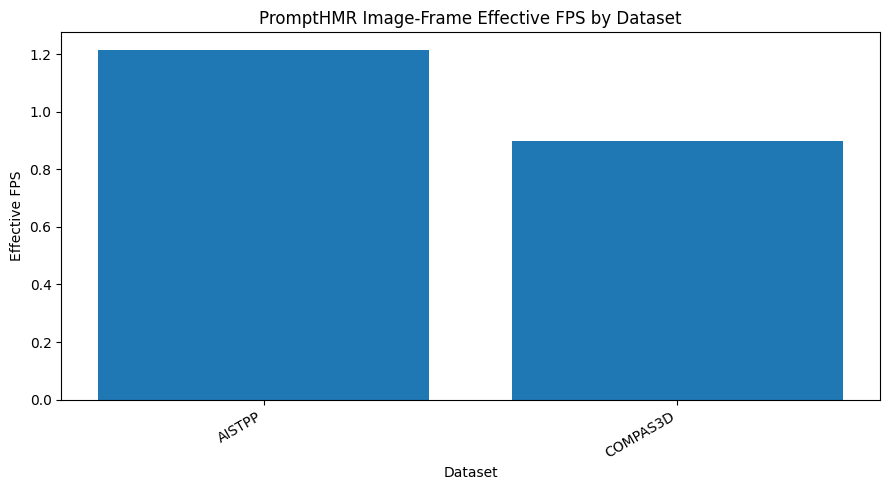

Saved: /home/cris-sx/UA/master-ia/tava/prompthmr-method/prompthmr-project/outputs/evaluation/prompthmr_image_frame_eval/reports/plots/prompt_hmr_image_frame_effective_fps.png
[SKIP] No finite values for: Processed_Frame_Success_Rate_% ↑
[SKIP] No finite values for: Frames_Without_Detection_% ↓
[SKIP] No finite values for: Overall_Finite_% ↑
[SKIP] No finite values for: Mesh_Largest_Extent_mm
[SKIP] No finite values for: Beta_Norm_Mean
[SKIP] No finite values for: Pose_Norm_Mean
[SKIP] No finite values for: Aux_Frame_Joint_Delta_L2_mm ↓


In [43]:
# CELL 25 REPLACEMENT: Plots for PromptHMR image/frame evaluation

import matplotlib.pyplot as plt

plot_dir = PROMPTHMR_REPORT_OUT / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)


def plot_bar_if_available(df, column, title, ylabel, filename):
    if df.empty:
        print(f"[SKIP] Empty DataFrame for {column}")
        return

    if column not in df.columns:
        print(f"[SKIP] Missing column: {column}")
        return

    plot_df = df[["dataset", column]].copy()
    plot_df[column] = pd.to_numeric(plot_df[column], errors="coerce")

    if plot_df[column].notna().sum() == 0:
        print(f"[SKIP] No finite values for: {column}")
        return

    plt.figure(figsize=(9, 5))
    plt.bar(plot_df["dataset"], plot_df[column])
    plt.title(title)
    plt.xlabel("Dataset")
    plt.ylabel(ylabel)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    path = plot_dir / filename
    plt.savefig(path, dpi=200)
    plt.show()

    print("Saved:", path)


if len(comparison_df) > 0:
    plot_bar_if_available(
        comparison_df,
        "Effective_FPS ↑",
        "PromptHMR Image-Frame Effective FPS by Dataset",
        "Effective FPS",
        "prompt_hmr_image_frame_effective_fps.png",
    )

    plot_bar_if_available(
        comparison_df,
        "Processed_Frame_Success_Rate_% ↑",
        "PromptHMR Processed Frame Success Rate by Dataset",
        "Success rate [%]",
        "prompt_hmr_processed_frame_success_rate.png",
    )

    plot_bar_if_available(
        comparison_df,
        "Frames_Without_Detection_% ↓",
        "PromptHMR Frames Without Detection by Dataset",
        "Frames without detection [%]",
        "prompt_hmr_frames_without_detection_percent.png",
    )

    plot_bar_if_available(
        comparison_df,
        "Overall_Finite_% ↑",
        "PromptHMR Numerical Validity by Dataset",
        "Finite values [%]",
        "prompt_hmr_overall_finite_percent.png",
    )

    plot_bar_if_available(
        comparison_df,
        "Mesh_Largest_Extent_mm",
        "PromptHMR Mesh Largest Extent by Dataset",
        "Largest mesh extent [mm]",
        "prompt_hmr_mesh_largest_extent.png",
    )

    plot_bar_if_available(
        comparison_df,
        "Beta_Norm_Mean",
        "PromptHMR Beta Norm by Dataset",
        "Mean beta norm",
        "prompt_hmr_beta_norm_mean.png",
    )

    plot_bar_if_available(
        comparison_df,
        "Pose_Norm_Mean",
        "PromptHMR Pose Vector Norm by Dataset",
        "Mean pose norm",
        "prompt_hmr_pose_norm_mean.png",
    )

    plot_bar_if_available(
        comparison_df,
        "Aux_Frame_Joint_Delta_L2_mm ↓",
        "PromptHMR Auxiliary Frame-to-Frame Joint Variation",
        "Mean joint delta L2 [mm]",
        "prompt_hmr_aux_frame_joint_delta.png",
    )

else:
    print("No comparison rows available for plotting.")

In [44]:
# CELL 26 REPLACEMENT: Generate corrected report paragraph for PromptHMR Section 3

report_txt = PROMPTHMR_REPORT_OUT / "prompt_hmr_section_3_report_text.txt"

lines = []

lines.append("3. Comparison with standard metrics using one or more datasets")
lines.append("")
lines.append(
    "For PromptHMR, the evaluation was implemented as an image/frame-based promptable HMR protocol. "
    "Although the input data are stored as short video clips, the clips were used only as containers "
    "from which RGB frames were sampled. PromptHMR was then applied independently to each sampled frame "
    "using YOLO person detections as spatial prompts. Therefore, this evaluation should not be interpreted "
    "as a native video-temporal evaluation of PromptHMR."
)
lines.append("")
lines.append(
    "For each sampled frame, the largest detected person was selected in order to maintain a consistent "
    "single-person evaluation protocol. The predicted PromptHMR outputs include SMPL-X pose parameters, "
    "shape parameters, 3D body joints, mesh vertices, camera intrinsics, translation, and bounding boxes."
)
lines.append("")
lines.append(
    "The pipeline was designed to be robust against corrupted or problematic input sources. Before frame "
    "sampling, each source video is checked with OpenCV. If the file cannot be opened or does not contain "
    "readable frames, it is marked as corrupt and skipped. During frame-level inference, individual frame "
    "failures are caught, logged, and skipped without interrupting the evaluation of the remaining inputs."
)
lines.append("")
lines.append(
    "The metrics are divided into two groups. First, standard ground-truth-dependent metrics are computed "
    "only when compatible annotations are available. These include MPJPE, PA-MPJPE, PCK at 150 mm, PVE/MPVPE, "
    "beta-parameter L2 error, and acceleration error. If no compatible ground truth is available, these "
    "accuracy metrics are intentionally left as NaN rather than being approximated incorrectly."
)
lines.append("")
lines.append(
    "Second, the evaluation reports primary ground-truth-free image/frame metrics. These metrics quantify "
    "deployment and prediction reliability rather than accuracy: processed-frame success rate, frames without "
    "detection, failed-frame rate, effective FPS, runtime, GPU memory usage, numerical finite-value percentage, "
    "bounding-box statistics, mesh extent sanity, beta-parameter magnitude, pose-vector magnitude, and translation "
    "magnitude."
)
lines.append("")
lines.append(
    "Some auxiliary frame-to-frame stability proxies are also reported, such as joint delta, vertex delta, "
    "pose delta, beta delta, and prediction acceleration magnitude. These values are computed over consecutive "
    "sampled frames, but they must be interpreted carefully: they are not native video-consistency metrics, "
    "because PromptHMR was applied independently to each frame and no temporal model was used."
)
lines.append("")
lines.append(
    "This protocol is appropriate for PromptHMR because PromptHMR is primarily evaluated here as a promptable "
    "image-based human mesh recovery method. Video-based methods such as VIBE or FastHMR-video should be "
    "evaluated separately under a true video-temporal protocol."
)
lines.append("")
lines.append("The final comparison-ready PromptHMR results are saved in:")
lines.append(str(comparison_csv))
lines.append("")
lines.append("Detailed inference summaries, metric tables, aggregate tables, and plots are saved in:")
lines.append(str(PROMPTHMR_REPORT_OUT))

report_txt.write_text("\n".join(lines))

print(report_txt.read_text())
print("\nSaved report text:", report_txt)

3. Comparison with standard metrics using one or more datasets

For PromptHMR, the evaluation was implemented as an image/frame-based promptable HMR protocol. Although the input data are stored as short video clips, the clips were used only as containers from which RGB frames were sampled. PromptHMR was then applied independently to each sampled frame using YOLO person detections as spatial prompts. Therefore, this evaluation should not be interpreted as a native video-temporal evaluation of PromptHMR.

For each sampled frame, the largest detected person was selected in order to maintain a consistent single-person evaluation protocol. The predicted PromptHMR outputs include SMPL-X pose parameters, shape parameters, 3D body joints, mesh vertices, camera intrinsics, translation, and bounding boxes.

The pipeline was designed to be robust against corrupted or problematic input sources. Before frame sampling, each source video is checked with OpenCV. If the file cannot be opened or does no